In [5]:
"""
这个脚本里面放的是所有的市场数据计算的工具函数

注意：
生成的series的name或者df的columns要以market_开头
"""





# 调用



## 用于存储不需要做特征工程的列的list
no_fe_list = []


def calc_market_turnover(client, start = datetime(2020, 1, 1, 0, 0, 0), end = datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场换手率
    全市场成交额/全市场流通市值

    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间

    返回：
    - series
    """
    money_df = client.get('index_money_1d', start, end)
    market_money = (money_df['000001.XSHG'] + money_df['399106.XSHE'])/100000000
    cir_cap = client.get('circulating_market_cap_1d', start, end)
    cir_cap = cir_cap.sum(axis=1)
    turnover = market_money / cir_cap
    turnover.name = 'market_turnover'
    return turnover




def calc_market_rise_fall_ratio(client, start = datetime(2020, 1, 1, 0, 0, 0), end = datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场涨跌比
    上涨股票数量/下跌股票数量

    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间

    返回：
    - series
    """
    # 获取股票收盘价数据
    close_df = client.get('close_1d', start, end)
    
    # 计算每日涨跌情况
    pct_change = close_df.pct_change()
    
    # 计算每日上涨股票数量
    rise_count = (pct_change > 0).sum(axis=1)
    
    # 计算每日下跌股票数量
    fall_count = (pct_change < 0).sum(axis=1)
    
    # 计算涨跌比（避免除零错误）
    rise_fall_ratio = rise_count / fall_count.replace(0, np.nan)
    rise_fall_ratio.name = 'market_rise_fall_ratio'
    
    return rise_fall_ratio





def _calc_slope(series, window):
    """
    计算series的滚动斜率
    
    参数:
    - series: 输入的时间序列
    - window: 滚动窗口大小
    
    返回:
    - 滚动斜率的series
    """
    def slope_func(x):
        if len(x) < window or x.isna().any():
            return np.nan
        y = x.values
        x_vals = np.arange(len(y))
        return np.polyfit(x_vals, y, 1)[0]
    
    return series.rolling(window=window).apply(slope_func, raw=False)





def calc_market_ma_info(client, start = datetime(2020, 1, 1, 0, 0, 0), end = datetime(2021, 6, 1, 0, 0, 0), slope_period=5):
    """
    计算市场均线的斜率

    这个函数计算出来会包含以下内容
    - slope_ma20_5: 市场20日均线的斜率，表示绝对趋势方向
    - diff_ma_5_20: 5日均线和20日均线的差值，表示相对趋势方向
    - ratio_ma_5_20: 5日均线和20日均线的比值，表示相对趋势强度
    - slope_diff_ma_5_20: 5日均线和20日均线差值的斜率，表示相对趋势的变化速度
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    - ma_period: 均线周期，默认20日均线
    - slope_period: 斜率计算周期，默认5日斜率
    
    返回：
    - 包含市场均线信息的df
    """

    market_price = client.get('index_close_1d', start, end)['000852.XSHG']
    
    ## 计算移动平均线
    ma5_series = market_price.rolling(window=5).mean()
    ma20_series = market_price.rolling(window=20).mean()
    
    ## 计算5日均线减去20日均线
    diff_ma_5_20 = ma5_series - ma20_series
    diff_ma_5_20.name = "market_diff_ma_5_20"

    ## 计算5日均线除以20日均线
    ratio_ma_5_20 = ma5_series / ma20_series
    ratio_ma_5_20.name = "market_ratio_ma_5_20"

    ## 计算5日均线和20日均线的斜率
    slope_diff_ma_5_20 = _calc_slope(diff_ma_5_20, slope_period)
    slope_diff_ma_5_20.name = "market_slope_diff_ma_5_20"

    ## 计算20日均线的斜率
    slope_ma20_5 = _calc_slope(ma20_series, slope_period)
    slope_ma20_5.name = "market_slope_ma20_5"

    ## 将四个series合并成一个DataFrame
    market_ma_info_df = pd.concat([diff_ma_5_20, ratio_ma_5_20, slope_diff_ma_5_20, slope_ma20_5], axis=1)

    market_ma_info_df.index = pd.to_datetime(market_ma_info_df.index)
    
    return market_ma_info_df



def calc_market_ta(client, start = datetime(2020, 1, 1, 0, 0, 0), end = datetime(2021, 6, 1, 0, 0, 0)):
    """
    使用talib计算市场技术指标
    包括macd_hist, rsi, kdj_k, bb_position, bb_width, atr, obv
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    
    返回：
    - 包含市场技术指标的df
    """

    ## 获取市场价格数据（使用中证1000作为市场代表）
    close = client.get("index_close_1d", start, end)['000852.XSHG']
    high = client.get("index_high_1d", start, end)['000852.XSHG']
    low = client.get("index_low_1d", start, end)['000852.XSHG']
    volume = client.get("index_volume_1d", start, end)['000852.XSHG']

    ## MACD指标
    macd, macd_signal, macd_hist = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    
    ## KDJ指标（使用STOCH计算K和D，然后计算J）
    k, d = ta.STOCH(high, low, close, fastk_period=9, slowk_period=3, slowd_period=3)
    
    ## RSI指标
    rsi = ta.RSI(close, timeperiod=14)
    
    ## 布林带
    bb_upper, bb_middle, bb_lower = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2)
    bb_width = (bb_upper - bb_lower) / bb_middle  ## 布林带宽度
    bb_position = (close - bb_lower) / (bb_upper - bb_lower)  ## 价格在布林带中的位置
    
    ## ATR (平均真实波幅)
    atr = ta.ATR(high, low, close, timeperiod=14)
    
    ## OBV (能量潮指标)
    obv = ta.OBV(close, volume)
    
    ## 创建DataFrame
    market_ta_df = pd.DataFrame({
        'market_macd_hist': macd_hist,
        'market_kdj_k': k,
        'market_rsi': rsi,
        'market_bb_width': bb_width,
        'market_bb_position': bb_position,
        'market_atr': atr,
        'market_obv': obv
    })
    
    market_ta_df.index = pd.to_datetime(market_ta_df.index)
    
    return market_ta_df



def calc_market_trend_regime(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0), 
                           window=30, trend_threshold=0.08, r2_threshold=0.35, vol_percentile=50):
    """
    用于计算市场趋势状态的函数，输出one-hot编码的趋势状态
    
    判定逻辑：
    1. 计算滚动回归斜率（年化）和R²
    2. 计算实现波动率（年化）
    3. 趋势判定：
       - uptrend: 年化斜率 > 8%, R² > 0.35, 波动率 < 历史50分位数
       - downtrend: 年化斜率 < -8%, R² > 0.35, 波动率 < 历史50分位数
       - volatile: 其他情况
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    - window: 回归窗口大小，默认30
    - trend_threshold: 趋势方向阈值，默认0.08 (8%)
    - r2_threshold: R²阈值，默认0.35
    - vol_percentile: 波动率分位数阈值，默认50
    
    返回：
    - DataFrame，包含市场趋势状态的one-hot编码
    """
    
    ## 获取市场价格数据（使用中证1000作为市场代表）
    market_price = client.get('index_close_1d', start, end)['000852.XSHG']
    log_price = np.log(market_price)
    
    def calc_slope(x):
        """计算回归斜率"""
        if len(x) < window or x.isna().any():
            return np.nan
        
        y = x.values
        x_vals = np.arange(len(y))
        slope, intercept = np.polyfit(x_vals, y, 1)
        return slope * 252  # 年化斜率
    
    def calc_r_squared(x):
        """计算R²"""
        if len(x) < window or x.isna().any():
            return np.nan
        
        y = x.values
        x_vals = np.arange(len(y))
        slope, intercept = np.polyfit(x_vals, y, 1)
        
        y_pred = slope * x_vals + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    ## 分别计算斜率和R²
    annualized_slope = log_price.rolling(window=window).apply(calc_slope, raw=False)
    r_squared = log_price.rolling(window=window).apply(calc_r_squared, raw=False)
    
    ## 计算年化实现波动率
    returns = log_price.pct_change()
    realized_vol = returns.rolling(window=window).std() * np.sqrt(252)

    ## 计算波动率的历史分位数阈值
    vol_threshold = realized_vol.rolling(window=252, min_periods=60).quantile(vol_percentile / 100)
    
    ## 判定趋势状态
    ## 上升趋势条件
    uptrend_condition = (
        (annualized_slope > trend_threshold) & 
        (r_squared > r2_threshold) & 
        (realized_vol < vol_threshold)
    )
    
    ## 下降趋势条件
    downtrend_condition = (
        (annualized_slope < -trend_threshold) & 
        (r_squared > r2_threshold) & 
        (realized_vol < vol_threshold)
    )
    
    ## 创建one-hot编码
    trend_regime_df = pd.DataFrame({
        'market_uptrend': uptrend_condition.astype(int),
        'market_downtrend': downtrend_condition.astype(int),
        'market_volatile': (~(uptrend_condition | downtrend_condition)).astype(int)
    }, index=market_price.index)
    
    trend_regime_df.index = pd.to_datetime(trend_regime_df.index)
    
    return trend_regime_df


def calc_market_volatility_level(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0), 
                                vol_window=30, lookback_window=120, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    """
    计算市场波动率水平，输出历史某个时间段内的波动率分位数
    
    这个函数会计算：
    1. 滚动波动率（年化）
    2. 历史lookback_window期间内的波动率分位数
    3. 当前波动率在历史分布中的位置
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    - vol_window: 波动率计算窗口，默认30天
    - lookback_window: 历史回望窗口，默认120天
    - quantiles: 需要计算的分位数列表，默认[0.1, 0.25, 0.5, 0.75, 0.9]
    
    返回：
    - DataFrame，包含当前波动率、历史分位数和波动率水平
    """
    
    ## 获取市场价格数据（使用中证1000作为市场代表）
    market_price = client.get('index_close_1d', start, end)['000852.XSHG']
    
    ## 计算日收益率
    returns = market_price.pct_change()
    
    ## 计算滚动波动率（年化）
    realized_vol = returns.rolling(window=vol_window).std() * np.sqrt(252)
    
    ## 计算历史波动率分位数
    vol_quantiles_df = pd.DataFrame(index=market_price.index)
    
    ## 添加当前波动率
    vol_quantiles_df['market_realized_vol'] = realized_vol
    
    ## 计算当前波动率在历史分布中的分位数位置，使用rank(pct=True)
    def calc_percentile_rank(x):
        """使用rank(pct=True)计算当前值在历史序列中的分位数位置"""
        if len(x) < 60:
            return np.nan
        return pd.Series(x).rank(pct=True).iloc[-1]
    
    market_vol_percentile = realized_vol.rolling(
        window=lookback_window, min_periods=60
    ).apply(calc_percentile_rank, raw=False)
    
    vol_quantiles_df['market_vol_percentile'] = market_vol_percentile
    
    ## 设置index为datetime格式
    vol_quantiles_df.index = pd.to_datetime(vol_quantiles_df.index)
    
    return vol_quantiles_df



def calc_market_volume_indicators(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场成交量相关指标
    
    包含：
    - market_volume_ma_ratio: 成交量与其20日均值的比值
    - market_volume_std_ratio: 成交量与其标准差的比值（Z-score）
    - market_volume_percentile: 成交量在历史120日的分位数位置
    - market_volume_trend: 成交量的5日趋势斜率
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    
    返回：
    - DataFrame，包含成交量相关指标
    """
    
    ## 获取市场成交量数据（使用中证1000）
    market_volume = client.get('index_volume_1d', start, end)['000852.XSHG']
    
    ## 成交量与20日均值的比值
    volume_ma20 = market_volume.rolling(window=20).mean()
    volume_ma_ratio = market_volume / volume_ma20
    
    ## 成交量的Z-score（标准化）
    volume_mean_60 = market_volume.rolling(window=60).mean()
    volume_std_60 = market_volume.rolling(window=60).std()
    volume_zscore = (market_volume - volume_mean_60) / volume_std_60
    
    ## 成交量在历史120日的分位数位置
    def calc_volume_percentile(x):
        if len(x) < 30:
            return np.nan
        return pd.Series(x).rank(pct=True).iloc[-1]
    
    volume_percentile = market_volume.rolling(
        window=120, min_periods=30
    ).apply(calc_volume_percentile, raw=False)
    
    ## 成交量的趋势斜率（使用对数变换，得到相对趋势）
    log_volume = np.log(market_volume)
    volume_trend = _calc_slope(log_volume, 5) * 100  # 转换为百分比/天
    
    ## 合并结果
    volume_indicators_df = pd.DataFrame({
        'market_volume_ma_ratio': volume_ma_ratio,
        'market_volume_zscore': volume_zscore,
        'market_volume_percentile': volume_percentile,
        'market_volume_trend': volume_trend
    })
    
    volume_indicators_df.index = pd.to_datetime(volume_indicators_df.index)
    
    return volume_indicators_df


def calc_market_money_flow(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场资金流向指标
    
    包含：
    - market_money_ma_ratio: 成交额与其20日均值的比值
    - market_money_percentile: 成交额在历史分布中的分位数位置
    - market_money_momentum: 成交额的动量指标（当日/5日前）
    - market_money_acceleration: 成交额动量的变化率
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    
    返回：
    - DataFrame，包含资金流向指标
    """
    
    ## 获取市场成交额数据
    money_df = client.get('index_money_1d', start, end)
    market_money = (money_df['000001.XSHG'] + money_df['399106.XSHE']) / 100000000  # 转换为亿元
    
    ## 成交额与20日均值的比值
    money_ma20 = market_money.rolling(window=20).mean()
    money_ma_ratio = market_money / money_ma20
    
    ## 成交额在历史分布中的分位数位置
    def calc_money_percentile(x):
        if len(x) < 30:
            return np.nan
        return pd.Series(x).rank(pct=True).iloc[-1]
    
    money_percentile = market_money.rolling(
        window=120, min_periods=30
    ).apply(calc_money_percentile, raw=False)
    
    ## 成交额动量（当日相对于5日前）
    money_momentum = market_money / market_money.shift(5)
    
    ## 成交额动量的加速度（动量的变化率）
    money_acceleration = money_momentum / money_momentum.shift(5)
    
    ## 合并结果
    money_flow_df = pd.DataFrame({
        'market_money_ma_ratio': money_ma_ratio,
        'market_money_percentile': money_percentile,
        'market_money_momentum': money_momentum,
        'market_money_acceleration': money_acceleration
    })
    
    money_flow_df.index = pd.to_datetime(money_flow_df.index)
    
    return money_flow_df


def calc_market_liquidity_stress(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场流动性压力指标
    
    包含：
    - market_turnover_vol_corr: 换手率与波动率的60日滚动相关性
    - market_price_volume_corr: 价格变化与成交量的相关性
    - market_liquidity_ratio: 成交额/波动率 (流动性效率)
    - market_impact_cost: 波动率/成交量 (市场冲击成本代理)
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    
    返回：
    - DataFrame，包含流动性压力指标
    """
    
    ## 获取基础数据
    market_price = client.get('index_close_1d', start, end)['000852.XSHG']
    market_volume = client.get('index_volume_1d', start, end)['000852.XSHG']
    money_df = client.get('index_money_1d', start, end)
    market_money = (money_df['000001.XSHG'] + money_df['399106.XSHE']) / 100000000
    
    ## 计算收益率和波动率
    returns = market_price.pct_change()
    realized_vol = returns.rolling(window=20).std() * np.sqrt(252)
    
    ## 计算换手率
    cir_cap = client.get('circulating_market_cap_1d', start, end).sum(axis=1)
    turnover = market_money / cir_cap
    
    ## 换手率与波动率的滚动相关性
    turnover_vol_corr = turnover.rolling(window=60).corr(realized_vol)
    
    ## 价格变化与成交量的相关性
    price_change = market_price.pct_change()
    price_volume_corr = price_change.rolling(window=60).corr(market_volume)
    
    ## 流动性效率比率（成交额/波动率）
    liquidity_ratio = market_money / (realized_vol + 1e-6)  # 避免除零
    
    ## 市场冲击成本代理（波动率/成交量）
    impact_cost = realized_vol / (market_volume / market_volume.rolling(20).mean() + 1e-6)
    
    ## 合并结果
    liquidity_stress_df = pd.DataFrame({
        'market_turnover_vol_corr': turnover_vol_corr,
        'market_price_volume_corr': price_volume_corr,
        'market_liquidity_ratio': liquidity_ratio,
        'market_impact_cost': impact_cost
    })
    
    liquidity_stress_df.index = pd.to_datetime(liquidity_stress_df.index)
    
    return liquidity_stress_df


def calc_market_participation(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0)):
    """
    计算市场参与度指标
    
    包含：
    - market_trading_stock_ratio: 有成交股票占比（非空成交量的股票）
    - market_volume_concentration: 成交量集中度（前20%股票的成交量占比）
    - market_breadth_momentum: 市场广度动量（上涨股票数的变化）
    - market_participation_index: 综合参与度指数
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    
    返回：
    - DataFrame，包含市场参与度指标
    """
    
    ## 获取数据
    close_df = client.get('close_1d', start, end)
    volume_df = client.get('volume_1d', start, end)
    
    ## 有成交数据的股票占比（改为基于总股票池）
    total_universe = 4500  # 假设总股票池约4500只
    trading_stocks = (~volume_df.isna()).sum(axis=1)
    trading_stock_ratio = trading_stocks / total_universe
    
    ## 成交量集中度（每日前20%股票的成交量占比）
    def calc_concentration(row):
        valid_volumes = row.dropna()
        if len(valid_volumes) < 10:
            return np.nan
        sorted_volumes = valid_volumes.sort_values(ascending=False)
        top_20_pct_count = max(1, int(len(sorted_volumes) * 0.2))
        return sorted_volumes.iloc[:top_20_pct_count].sum() / sorted_volumes.sum()
    
    volume_concentration = volume_df.apply(calc_concentration, axis=1)
    
    ## 市场广度动量（基于涨跌股票数量变化）
    pct_change = close_df.pct_change()
    rising_stocks = (pct_change > 0).sum(axis=1)
    falling_stocks = (pct_change < 0).sum(axis=1)
    
    # 计算净上涨股票数的5日变化
    net_rising = rising_stocks - falling_stocks
    breadth_momentum = net_rising - net_rising.shift(5)
    
    ## 计算更稳健的参与度指数
    # 使用移动平均来计算基准值，避免除零
    trading_ratio_ma = trading_stock_ratio.rolling(window=60, min_periods=20).mean()
    trading_ratio_std = trading_stock_ratio.rolling(window=60, min_periods=20).std()
    
    concentration_ma = volume_concentration.rolling(window=60, min_periods=20).mean() 
    concentration_std = volume_concentration.rolling(window=60, min_periods=20).std()
    
    breadth_ma = breadth_momentum.rolling(window=60, min_periods=20).mean()
    breadth_std = breadth_momentum.rolling(window=60, min_periods=20).std()
    
    # 标准化（避免除零）
    trading_norm = (trading_stock_ratio - trading_ratio_ma) / (trading_ratio_std + 1e-6)
    concentration_norm = (volume_concentration - concentration_ma) / (concentration_std + 1e-6)  
    breadth_norm = (breadth_momentum - breadth_ma) / (breadth_std + 1e-6)
    
    # 计算综合指数（交易参与度正向，集中度负向，广度正向）
    participation_index = (trading_norm * 0.4 - concentration_norm * 0.3 + breadth_norm * 0.3)
    
    ## 合并结果
    participation_df = pd.DataFrame({
        'market_trading_stock_ratio': trading_stock_ratio,
        'market_volume_concentration': volume_concentration,
        'market_breadth_momentum': breadth_momentum,
        'market_participation_index': participation_index
    })
    
    participation_df.index = pd.to_datetime(participation_df.index)
    
    return participation_df


def calc_all_market_indicators(client, start=datetime(2020, 1, 1, 0, 0, 0), end=datetime(2021, 6, 1, 0, 0, 0), 
                             save_csv=True, csv_path=None):
    """
    便捷函数：调用所有市场指标计算函数，将结果拼接成一个完整的DataFrame
    
    参数:
    - client: 数据库客户端
    - start: 开始时间
    - end: 结束时间
    - save_csv: 是否保存为CSV文件，默认True
    - csv_path: CSV文件保存路径，如果为None则自动生成路径
    
    返回：
    - DataFrame，包含所有市场指标
    """
    
    print("开始计算所有市场指标...")
    
    # 调用所有计算函数
    print("1. 计算市场换手率...")
    turnover = calc_market_turnover(client, start, end)
    
    print("2. 计算市场涨跌比...")
    rise_fall_ratio = calc_market_rise_fall_ratio(client, start, end)
    
    print("3. 计算市场均线信息...")
    ma_info = calc_market_ma_info(client, start, end)
    
    print("4. 计算市场技术指标...")
    ta_indicators = calc_market_ta(client, start, end)
    
    print("5. 计算市场趋势状态...")
    trend_regime = calc_market_trend_regime(client, start, end)
    
    print("6. 计算市场波动率水平...")
    volatility_level = calc_market_volatility_level(client, start, end)
    
    print("7. 计算市场成交量指标...")
    volume_indicators = calc_market_volume_indicators(client, start, end)
    
    print("8. 计算市场资金流向...")
    money_flow = calc_market_money_flow(client, start, end)
    
    print("9. 计算市场流动性压力...")
    liquidity_stress = calc_market_liquidity_stress(client, start, end)
    
    print("10. 计算市场参与度...")
    participation = calc_market_participation(client, start, end)
    
    print("合并所有指标...")
    
    # 将所有结果合并到一个DataFrame中
    # 使用outer join确保不丢失任何日期
    all_indicators = pd.concat([
        turnover,
        rise_fall_ratio,
        ma_info,
        ta_indicators,
        trend_regime,
        volatility_level,
        volume_indicators,
        money_flow,
        liquidity_stress,
        participation
    ], axis=1, join='outer')
    
    # 确保index是datetime格式并排序
    all_indicators.index = pd.to_datetime(all_indicators.index)
    all_indicators = all_indicators.sort_index()
    
    # 添加日期列便于查看
    all_indicators.reset_index(inplace=True)
    all_indicators.rename(columns={'index': 'date'}, inplace=True)
    
    print(f"计算完成！共生成 {len(all_indicators)} 行数据，{len(all_indicators.columns)-1} 个指标")
    
    # 保存为CSV文件
    if save_csv:
        if csv_path is None:
            # 生成默认文件名，包含时间范围
            start_str = start.strftime('%Y%m%d')
            end_str = end.strftime('%Y%m%d')
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            csv_path = f"market_indicators_{start_str}_{end_str}_{timestamp}.csv"
        
        all_indicators.to_csv(csv_path, index=False, encoding='utf-8')
        print(f"数据已保存到: {csv_path}")
    
    return all_indicators


In [4]:

# 调用
from weike_quant_db import Clickhouse
client = Clickhouse(database="default", host="10.0.10.12", port=8123, username="read_only_user", password="password", readonly=True)



import numpy as np
import pandas as pd
from datetime import datetime

import talib as ta

✅ 从包数据文件加载成功
✅ 因子功能已启用
✅ ClickHouse连接成功: read_only_user@10.0.10.12:8123/default


In [6]:

if __name__ == "__main__":
    # 创建默认的client用于测试
    default_client = Clickhouse(database="default", host="10.0.10.12", port=8123, username="weike", password="1w9bt7pYj9Wp5p")
    
    # 测试单个函数
    # print(calc_market_trend_regime(default_client))
    
    # 测试完整的市场指标计算
    result_df = calc_all_market_indicators(
        default_client, 
        start=datetime(2025, 1, 1), 
        end=datetime(2025, 6, 30),
        save_csv=True
    )
    print("\n前5行数据预览:")
    print(result_df.head())
    print(f"\n数据形状: {result_df.shape}")
    print(f"\n所有列名:")
    for i, col in enumerate(result_df.columns, 1):
        print(f"{i:2d}. {col}")

✅ 从包数据文件加载成功
✅ 因子功能已启用
✅ ClickHouse连接成功: weike@10.0.10.12:8123/default
开始计算所有市场指标...
1. 计算市场换手率...
2. 计算市场涨跌比...
3. 计算市场均线信息...
4. 计算市场技术指标...
5. 计算市场趋势状态...
6. 计算市场波动率水平...
7. 计算市场成交量指标...
8. 计算市场资金流向...
9. 计算市场流动性压力...
10. 计算市场参与度...
合并所有指标...
计算完成！共生成 117 行数据，34 个指标
数据已保存到: market_indicators_20250101_20250630_20251210_144138.csv

前5行数据预览:
        date  market_turnover  market_rise_fall_ratio  market_diff_ma_5_20  \
0 2025-01-02         0.018572                     NaN                  NaN   
1 2025-01-03         0.017185                0.106536                  NaN   
2 2025-01-06         0.014376                0.788392                  NaN   
3 2025-01-07         0.014480                4.772675                  NaN   
4 2025-01-08         0.016735                0.570570                  NaN   

   market_ratio_ma_5_20  market_slope_diff_ma_5_20  market_slope_ma20_5  \
0                   NaN                        NaN                  NaN   
1                   NaN              

In [10]:
import pandas as pd

parquet_path = "/Users/yulia/Desktop/clickhouse/market_indicators_20200101_20241231_20251109_132634.parquet"

# ============ 1) 读取旧 parquet ============

df_old = pd.read_parquet(parquet_path)

# 确保 index 是 DatetimeIndex
if not isinstance(df_old.index, pd.DatetimeIndex):
    df_old.index = pd.to_datetime(df_old.index, errors="coerce")

df_old = df_old.sort_index()

# 把之前误合的 1970-01-01 删掉（如果有）
df_old = df_old[df_old.index >= "2000-01-01"]

print("Old date range (cleaned):", df_old.index.min(), "→", df_old.index.max(), "shape:", df_old.shape)

# ============ 2) 处理新结果 result_df ============

df_new = result_df.copy()

# 用 date 列作为索引
df_new["date"] = pd.to_datetime(df_new["date"])
df_new = df_new.set_index("date").sort_index()

# 只保留 2025-01-01 ~ 2025-06-30
df_new = df_new.loc["2025-01-01":"2025-06-30"]

print("New df date range:", df_new.index.min(), "→", df_new.index.max(), "shape:", df_new.shape)

# ============ 3) 对齐列并合并（新数据优先）===========

all_cols = sorted(set(df_old.columns) | set(df_new.columns))
df_old = df_old.reindex(columns=all_cols)
df_new = df_new.reindex(columns=all_cols)

df_merged = pd.concat([df_old, df_new])

# 相同日期保留“最后一条”（即用 df_new 覆盖 df_old）
df_merged = df_merged[~df_merged.index.duplicated(keep="last")]
df_merged = df_merged.sort_index()

print("Merged date range:", df_merged.index.min(), "→", df_merged.index.max(), "shape:", df_merged.shape)

# ============ 4) 写回 parquet（覆盖原文件）===========

df_merged.to_parquet(parquet_path)
print("✅ Saved merged parquet to:", parquet_path)


Old date range (cleaned): 2020-01-02 00:00:00 → 2024-12-31 00:00:00 shape: (1212, 35)
New df date range: 2025-01-02 00:00:00 → 2025-06-30 00:00:00 shape: (117, 34)
Merged date range: 2020-01-02 00:00:00 → 2025-06-30 00:00:00 shape: (1329, 35)
✅ Saved merged parquet to: /Users/yulia/Desktop/clickhouse/market_indicators_20200101_20241231_20251109_132634.parquet


In [11]:
check = pd.read_parquet(parquet_path)
print(check.index.min(), "→", check.index.max())


2020-01-02 00:00:00 → 2025-06-30 00:00:00


In [11]:
# 假设你的 DataFrame 名叫 df
df = pd.read_csv("market_indicators_20200101_20241231_20251109_132634.csv")

# 去掉日期列
feature_cols = [c for c in df.columns if c != "date"]

# 1️⃣ 总特征数量
print(f"共有特征数量: {len(feature_cols)}")

# 2️⃣ 统计每列非空值数量和比例
non_nan_stats = pd.DataFrame({
    "non_nan_count": df[feature_cols].notna().sum(),
    "non_nan_ratio": df[feature_cols].notna().mean()
}).sort_values("non_nan_ratio", ascending=False)

# 3️⃣ 显示前后几行预览
display(non_nan_stats.head(10))
display(non_nan_stats.tail(10))

# 如果想保存成CSV方便查看
non_nan_stats.to_csv("market_feature_non_nan_stats.csv", encoding="utf-8-sig")


共有特征数量: 34


,non_nan_count,non_nan_ratio
market_turnover,1212,1.000000
market_uptrend,1212,1.000000
market_trading_stock_ratio,1212,1.000000
market_volume_concentration,1212,1.000000
market_volatile,1212,1.000000
market_downtrend,1212,1.000000
market_obv,1212,1.000000
market_rise_fall_ratio,1211,0.999175
market_volume_trend,1208,0.996700
market_money_momentum,1207,0.995875


,non_nan_count,non_nan_ratio
market_slope_diff_ma_5_20,1189,0.981023
market_participation_index,1188,0.980198
market_money_percentile,1183,0.976073
market_volume_percentile,1183,0.976073
market_realized_vol,1182,0.975248
market_macd_hist,1179,0.972772
market_volume_zscore,1153,0.951320
market_price_volume_corr,1152,0.950495
market_turnover_vol_corr,1133,0.934818
market_vol_percentile,1123,0.926568


In [15]:
# ======= D. 市场特征（从CSV加载，D类） =======

# 1) 读入你刚刚生成的市场指标文件
mkt_df = pd.read_csv("market_indicators_20200101_20241231_20251109_132634.csv")

# 2) 处理日期 & 设为索引
mkt_df["date"] = pd.to_datetime(mkt_df["date"])
mkt_df = mkt_df.set_index("date").sort_index()

# 3) 如果前面已经有 trade_days，就用 trade_days 对齐；
#    否则，就直接把 mkt_df 的索引当作 trade_days
if "trade_days" in globals():
    mkt_df = mkt_df.reindex(trade_days)
    trade_days_D = trade_days
else:
    trade_days_D = mkt_df.index

# 4) 选出特征列（去掉全 NaN 的列）
feature_cols_D = list(mkt_df.columns)   # 现在除了 date，其它都是特征
features_D = mkt_df[feature_cols_D].dropna(how="all", axis=1)

print(f"市场特征D类：共有 {features_D.shape[1]} 个特征")
print("示例列名：", list(features_D.columns)[:10])
print("数据形状：", features_D.shape)

# 5) 看每个特征的非NaN比例（方便 you sanity check）
non_nan_stats_D = pd.DataFrame({
    "non_nan_count": features_D.notna().sum(),
    "non_nan_ratio": features_D.notna().mean()
}).sort_values("non_nan_ratio", ascending=False)

print("=== D类市场特征非NaN比例 ===")
print(non_nan_stats_D.head(10))
print(non_nan_stats_D.tail(10))


市场特征D类：共有 34 个特征
示例列名： ['market_turnover', 'market_rise_fall_ratio', 'market_diff_ma_5_20', 'market_ratio_ma_5_20', 'market_slope_diff_ma_5_20', 'market_slope_ma20_5', 'market_macd_hist', 'market_kdj_k', 'market_rsi', 'market_bb_width']
数据形状： (1212, 34)
=== D类市场特征非NaN比例 ===
                             non_nan_count  non_nan_ratio
market_turnover                       1212       1.000000
market_uptrend                        1212       1.000000
market_trading_stock_ratio            1212       1.000000
market_volume_concentration           1212       1.000000
market_volatile                       1212       1.000000
market_downtrend                      1212       1.000000
market_obv                            1212       1.000000
market_rise_fall_ratio                1211       0.999175
market_volume_trend                   1208       0.996700
market_money_momentum                 1207       0.995875
                            non_nan_count  non_nan_ratio
market_slope_diff_ma_5_20     

In [3]:
# ======= 0. 基本配置 & 引用 =======
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 如果你在这个 ipynb 里还没建过 client，就取消下面注释，自行填好参数：
from weike_quant_db import Clickhouse
client = Clickhouse(
    database="default",
    host="10.0.10.12",
    port=8123,
    username="read_only_user",
    password="password",
    readonly=True,
)

# 指数&样本区间&标签参数（保持和你ABC那份一致）
INDEX_CODE = "zz1000"         # "zz1000" / "hs300" / "zz500"
H = 20                         # 未来H日累计对数收益
START_DATE = datetime(2023, 1, 1)
END_DATE   = datetime(2025, 6, 30)

# ======= 1. 取交易日、价格、权重，构造 label =======

# 1.1 交易日
is_trade_df = client.get('is_trade_day', START_DATE, END_DATE).sort_index()
trade_days = is_trade_df.index

# 1.2 个股收盘价（多取365天用于logret）
close_df  = client.get('close_1d', START_DATE - timedelta(days=365), END_DATE).sort_index()

# 1.3 指数权重（用于合成指数收益）
weight_df = client.get(f"{INDEX_CODE}_weight", START_DATE, END_DATE).sort_index()

# 列名规范化：去掉 .SH/.SZ 之类
def _norm_cols(df):
    if not isinstance(df, pd.DataFrame):
        return df
    out = df.copy()
    out.columns = [
        str(c).replace('.SZ','').replace('.SH','').replace('SZ','').replace('SH','')
        for c in out.columns
    ]
    return out

close_df  = _norm_cols(close_df).reindex(trade_days).ffill().sort_index()
weight_df = _norm_cols(weight_df).reindex(trade_days).fillna(0.0).sort_index()

# 权重按天归一
w_sum = weight_df.sum(axis=1).replace(0, np.nan)
weight_df = weight_df.div(w_sum, axis=0).fillna(0.0)

# 1.4 构造指数 log return & label
stock_logret = np.log(close_df).diff()
index_logret = (weight_df * stock_logret).sum(axis=1).rename(f"{INDEX_CODE}_logret")

# 未来 H 日累计 logret 作为标签，向前平移 H 天（预测未来）
label = index_logret.rolling(H).sum().shift(-H).rename(f"RET_{INDEX_CODE}_{H}d")

print("标签 label 基本信息：")
print(label.describe())
print("标签前5行：")
print(label.head())

# ======= 2. 从 CSV 读取 D 类市场特征 =======

# 2.1 读入你已经生成好的市场指标文件
mkt_df = pd.read_csv("market_indicators_20200101_20241231_20251109_132634.csv")

# 2.2 处理日期 & 设为索引
mkt_df["date"] = pd.to_datetime(mkt_df["date"])
mkt_df = mkt_df.set_index("date").sort_index()

# 2.3 对齐交易日（只保留与 trade_days 重叠部分）
mkt_df = mkt_df.reindex(trade_days)

# 2.4 选出所有市场特征列（现在 index 已经是 date）
#     如果你确定这份 CSV 只有 35 个指标 + date，那这一步就是那 35 个
feature_cols_D = list(mkt_df.columns)
features_D = mkt_df[feature_cols_D].dropna(how="all", axis=1)

print(f"\nD类市场特征：共有 {features_D.shape[1]} 个特征")
print("示例列名：", list(features_D.columns)[:10])
print("数据形状：", features_D.shape)

# 2.5 每个特征的非NaN比例（sanity check）
non_nan_stats_D = pd.DataFrame({
    "non_nan_count": features_D.notna().sum(),
    "non_nan_ratio": features_D.notna().mean()
}).sort_values("non_nan_ratio", ascending=False)

print("\n=== D类市场特征非NaN比例（Top 10） ===")
print(non_nan_stats_D.head(10))
print("\n=== D类市场特征非NaN比例（Tail 10） ===")
print(non_nan_stats_D.tail(10))

# ======= 3. 评价函数：RankIC / HitRatio =======

def rankic(x, y):
    return spearmanr(x, y, nan_policy="omit")[0]

def hit(x, y):
    # 方向是否同号
    return float((np.sign(x) * np.sign(y) > 0).mean())

def evaluate_features(feat_df: pd.DataFrame, label_series: pd.Series) -> pd.DataFrame:
    """
    对给定的一组特征（列）与标签，计算：
    - RankIC_raw / HitRatio_raw
    - 使用 252 日滚动标准化后的 RankIC_std / HitRatio_std
    - n_obs：特征和标签同时非NaN的样本数
    """
    # 252日滚动z-score标准化
    feat_std = (feat_df - feat_df.rolling(252, min_periods=60).mean()) \
                         / feat_df.rolling(252, min_periods=60).std()

    # 原始值与标签对齐
    df_eval = pd.concat([feat_df, label_series], axis=1).dropna()

    # 标准化值与标签对齐
    df_eval_std = pd.concat([feat_std, label_series], axis=1).dropna()

    rows = []
    for col in feat_df.columns:
        # 原始 RankIC / HitRatio
        if col in df_eval.columns:
            ic_raw = rankic(df_eval[col], df_eval[label_series.name])
            hr_raw = hit(df_eval[col], df_eval[label_series.name])
            n_obs  = int(df_eval[[col, label_series.name]].dropna().shape[0])
        else:
            ic_raw = hr_raw = np.nan
            n_obs  = 0

        # 标准化后的 RankIC / HitRatio
        if col in df_eval_std.columns:
            ic_std = rankic(df_eval_std[col], df_eval_std[label_series.name])
            hr_std = hit(df_eval_std[col], df_eval_std[label_series.name])
        else:
            ic_std = hr_std = np.nan

        rows.append({
            "feature": col,
            "label":   label_series.name,
            "RankIC_raw": ic_raw,
            "HitRatio_raw": hr_raw,
            "RankIC_std": ic_std,
            "HitRatio_std": hr_std,
            "n_obs": n_obs
        })

    return pd.DataFrame(rows).sort_values("RankIC_std", ascending=False)

# ======= 4. 计算 D 类特征的表现 =======

summary_D = evaluate_features(features_D, label)
summary_D["bucket"] = "市场特征D类"

summary_D_sorted = summary_D.sort_values("RankIC_std", ascending=False)

print("\n=== 市场特征D类 summary_D（按 RankIC_std 排序，Top 20） ===")
print(summary_D_sorted)



✅ 从包数据文件加载成功
✅ 因子功能已启用
✅ ClickHouse连接成功: read_only_user@10.0.10.12:8123/default


KeyboardInterrupt: 

In [19]:
# ======= 从 timing_feature 文件夹读取 A/B/C 特征与评估结果 =======
import pandas as pd

INDEX_CODE = "zz1000"
START_STR = "20230101"
END_STR   = "20250630"

# 1）读取 summary 文件
summary_A = pd.read_csv(f"timing_feature/summary_A_{INDEX_CODE}_{START_STR}_{END_STR}.csv")
summary_B = pd.read_csv(f"timing_feature/summary_B_{INDEX_CODE}_{START_STR}_{END_STR}.csv")
summary_C = pd.read_csv(f"timing_feature/summary_C_{INDEX_CODE}_{START_STR}_{END_STR}.csv")
summary_ABC_all = pd.read_csv(f"timing_feature/summary_ABC_all_{INDEX_CODE}_{START_STR}_{END_STR}.csv")

print("✅ 已加载 summary_A/B/C/All：")
print("summary_ABC_all 预览：")
print(summary_ABC_all.head())

# 2）如果你需要加载 A/B/C 因子时间序列
features_ABC = pd.read_csv(
    f"timing_feature/features_ABC_{INDEX_CODE}_{START_STR}_{END_STR}.csv",
    parse_dates=["date"],
    index_col="date"
)

print("\n✅ 已加载 features_ABC：")
print("行列数：", features_ABC.shape)
print("前5行预览：")
print(features_ABC.head())


✅ 已加载 summary_A/B/C/All：
summary_ABC_all 预览：
                     feature           label  RankIC_raw  HitRatio_raw  \
0       vp_turnover_weighted  RET_zz1000_20d    0.205669      0.385057   
1    vp_money_ma10_over_ma60  RET_zz1000_20d    0.012506      0.385057   
2  vp_turnover_extreme_score  RET_zz1000_20d    0.145311      0.555556   
3    vp_top20cap_money_share  RET_zz1000_20d    0.227176      0.385057   
4          vp_volatility_20d  RET_zz1000_20d    0.329041      0.385057   

   RankIC_std  HitRatio_std  n_obs bucket  
0    0.254929      0.609071    522    量价类  
1    0.231169      0.606911    522    量价类  
2    0.202252      0.589633    522  风格结构类  
3    0.191214      0.542117    522  风格结构类  
4    0.184529      0.494600    522    量价类  

✅ 已加载 features_ABC：
行列数： (601, 22)
前5行预览：
            vp_volatility_20d  vp_advance_breadth  \
date                                                
2023-01-03                NaN               0.000   
2023-01-04                NaN               

In [20]:
import pandas as pd
import os

INDEX_CODE = "zz1000"
START_STR = "20230101"
END_STR   = "20250630"

# ===== 1. 读取 A/B/C 的 summary =====
summary_A = pd.read_csv(f"timing_feature/summary_A_{INDEX_CODE}_{START_STR}_{END_STR}.csv")
summary_B = pd.read_csv(f"timing_feature/summary_B_{INDEX_CODE}_{START_STR}_{END_STR}.csv")
summary_C = pd.read_csv(f"timing_feature/summary_C_{INDEX_CODE}_{START_STR}_{END_STR}.csv")

# 给ABC补上 bucket 信息（如果当初保存时没有带）
if "bucket" not in summary_A.columns:
    summary_A["bucket"] = "量价类"
if "bucket" not in summary_B.columns:
    summary_B["bucket"] = "风格结构类"
if "bucket" not in summary_C.columns:
    summary_C["bucket"] = "资金情绪类"

# ===== 2. 获取 D 类 summary =====
# 情况1：你已经在这个 notebook 里算过 summary_D
if "summary_D" in globals():
    summary_D_use = summary_D.copy()
else:
    # 情况2：之前把 D 类结果存成 CSV（按你之前的命名改一下）
    summary_D_use = pd.read_csv("summary_D_market_features.csv")

# 确保有 bucket 列
if "bucket" not in summary_D_use.columns:
    summary_D_use["bucket"] = "市场特征D类"

# ===== 3. 合并 ABCD 四类 summary =====
summary_ABCD_all = pd.concat(
    [summary_A, summary_B, summary_C, summary_D_use],
    axis=0,
    ignore_index=True
)

# 按 RankIC_std 排序
summary_ABCD_all = summary_ABCD_all.sort_values("RankIC_std", ascending=False)

# 建议统一保存到 timing_feature 文件夹
os.makedirs("timing_feature", exist_ok=True)
save_path = f"timing_feature/summary_ABCD_all_{INDEX_CODE}_{START_STR}_{END_STR}.csv"
summary_ABCD_all.to_csv(save_path, encoding="utf-8-sig", index=False)

print("✅ 已生成 ABCD 四类因子总排行榜：", save_path)
print("\n=== Top 20 因子（按 RankIC_std） ===")
print(summary_ABCD_all.head(20))


✅ 已生成 ABCD 四类因子总排行榜： timing_feature/summary_ABCD_all_zz1000_20230101_20250630.csv

=== Top 20 因子（按 RankIC_std） ===
                         feature           label  RankIC_raw  HitRatio_raw  \
22                    market_atr  RET_zz1000_20d    0.168201      0.349174   
23            market_impact_cost  RET_zz1000_20d    0.080114      0.349174   
24           market_realized_vol  RET_zz1000_20d    0.136329      0.349174   
0           vp_turnover_weighted  RET_zz1000_20d    0.205669      0.385057   
25               market_bb_width  RET_zz1000_20d    0.201456      0.349174   
1        vp_money_ma10_over_ma60  RET_zz1000_20d    0.012506      0.385057   
26         market_vol_percentile  RET_zz1000_20d    0.129186      0.349174   
27      market_volume_percentile  RET_zz1000_20d    0.185692      0.349174   
28          market_volume_zscore  RET_zz1000_20d    0.278588      0.595041   
29        market_volume_ma_ratio  RET_zz1000_20d    0.232811      0.349174   
7      vp_turnover_extreme_

In [21]:
# 只看有 bucket 的列
group_stats = (
    summary_ABCD_all
    .groupby("bucket")[["RankIC_std", "HitRatio_std", "n_obs"]]
    .agg({
        "RankIC_std": ["mean", "median"],
        "HitRatio_std": ["mean", "median"],
        "n_obs": "mean"
    })
)

print("=== 按类别聚合的表现（RankIC_std / HitRatio_std） ===")
print(group_stats)


=== 按类别聚合的表现（RankIC_std / HitRatio_std） ===
       RankIC_std           HitRatio_std            n_obs
             mean    median         mean    median   mean
bucket                                                   
市场特征D类   0.028816  0.050988     0.520644  0.530189  484.0
资金情绪类    0.071336  0.064081     0.524554  0.548828  571.0
量价类      0.080161  0.134895     0.510336  0.498920  522.0
风格结构类    0.070549  0.064511     0.520248  0.516199  522.0


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 配置阈值（可以自己调） =====
POS_TH = 0.05   # 认为是“有效正向因子”的下限
NEG_TH = -0.05  # 认为是“有效反向因子”的上限
NOISE_TH = 0.02 # 绝对值小于此视为“几乎无效”

# 如果 summary_D 不在内存，可以先读
# summary_D = pd.read_csv("timing_feature/summary_D_market_features.csv")

df_D = summary_D.copy()

# 防御一下缺失值
df_D["RankIC_std"] = df_D["RankIC_std"].astype(float)

# ===== 定义一个方向判定函数 =====
def classify_direction(ic):
    if np.isnan(ic):
        return "no_data"
    if ic >= POS_TH:
        return "pos_strong"   # 有效正向
    if ic <= NEG_TH:
        return "neg_strong"   # 有效反向
    if abs(ic) <= NOISE_TH:
        return "noise"        # 基本无效
    # 介于 noise 和 strong 之间
    if ic > 0:
        return "pos_weak"     # 弱正向
    else:
        return "neg_weak"     # 弱反向

# 方向标签 & 数值方向（+1 / -1 / 0）
df_D["direction_tag"] = df_D["RankIC_std"].apply(classify_direction)
df_D["direction_sign"] = df_D["RankIC_std"].apply(
    lambda x: 1 if x >= POS_TH else (-1 if x <= NEG_TH else 0)
)

# ===== 按类别统计数量（这里只是 D 类，但也方便看分布） =====
print("=== D类市场特征 方向分类统计 ===")
print(df_D["direction_tag"].value_counts())

print("\n=== D类市场特征 明细（按 RankIC_std 排序） ===")
print(df_D.sort_values("RankIC_std", ascending=False)[
    ["feature", "RankIC_std", "HitRatio_std", "n_obs", "direction_tag", "direction_sign"]
])

# ===== 保存一份方向判定表到 timing_feature 文件夹 =====
import os
os.makedirs("timing_feature", exist_ok=True)
df_D.to_csv("timing_feature/summary_D_with_direction.csv", encoding="utf-8-sig", index=False)
print("\n✅ 已保存 summary_D_with_direction.csv 到 timing_feature/")


=== D类市场特征 方向分类统计 ===
direction_tag
pos_strong    17
neg_strong    12
noise          3
pos_weak       1
neg_weak       1
Name: count, dtype: int64

=== D类市场特征 明细（按 RankIC_std 排序） ===
                        feature  RankIC_std  HitRatio_std  n_obs  \
11                   market_atr    0.392500      0.596226    484   
29           market_impact_cost    0.286215      0.437736    484   
16          market_realized_vol    0.276754      0.464151    484   
9               market_bb_width    0.238769      0.581132    484   
17        market_vol_percentile    0.230897      0.422642    484   
20     market_volume_percentile    0.223987      0.592453    484   
19         market_volume_zscore    0.207402      0.603774    484   
18       market_volume_ma_ratio    0.202322      0.626415    484   
22        market_money_ma_ratio    0.160677      0.637736    484   
14             market_downtrend    0.159292      0.630189    484   
0               market_turnover    0.157086      0.577358    484   
2

=== 各类因子方向分类统计 ===
bucket  direction_tag
市场特征D类  neg_strong       12
        neg_weak          1
        noise             3
        pos_strong       17
        pos_weak          1
资金情绪类   neg_strong        1
        pos_strong        5
        pos_weak          1
量价类     neg_strong        2
        pos_strong        4
        pos_weak          1
风格结构类   neg_strong        1
        noise             1
        pos_strong        5
        pos_weak          1
Name: feature, dtype: int64

✅ 已保存 ABCD 全部因子的方向判定表到 timing_feature/


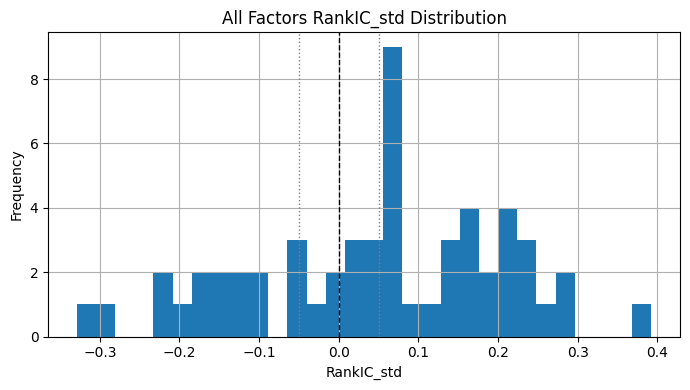

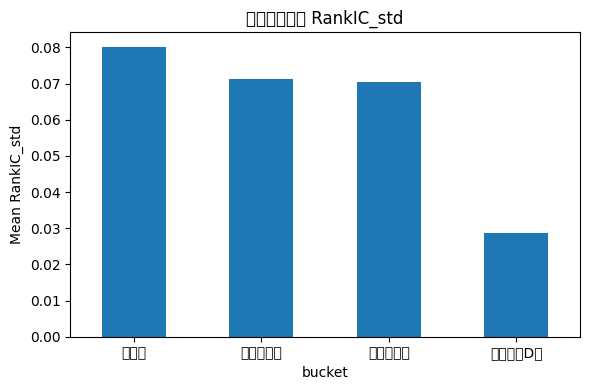

In [23]:
# 假设这里已经有 summary_ABCD_all（来自前面合并 ABCD 的代码）
df_all = summary_ABCD_all.copy()
df_all["RankIC_std"] = df_all["RankIC_std"].astype(float)

# 如果刚才已经定义过 classify_direction / POS_TH 等，这里就不用重复定义；
# 否则再执行一次定义（保险起见可以保留）

def classify_direction(ic):
    if np.isnan(ic):
        return "no_data"
    if ic >= POS_TH:
        return "pos_strong"
    if ic <= NEG_TH:
        return "neg_strong"
    if abs(ic) <= NOISE_TH:
        return "noise"
    if ic > 0:
        return "pos_weak"
    else:
        return "neg_weak"

df_all["direction_tag"] = df_all["RankIC_std"].apply(classify_direction)
df_all["direction_sign"] = df_all["RankIC_std"].apply(
    lambda x: 1 if x >= POS_TH else (-1 if x <= NEG_TH else 0)
)

print("=== 各类因子方向分类统计 ===")
print(df_all.groupby(["bucket", "direction_tag"])["feature"].count())

# 保存一份完整带方向的表
df_all.to_csv(
    f"timing_feature/summary_ABCD_all_with_direction_{INDEX_CODE}_{START_STR}_{END_STR}.csv",
    encoding="utf-8-sig",
    index=False
)
print("\n✅ 已保存 ABCD 全部因子的方向判定表到 timing_feature/")

# ===== 画一个 RankIC_std 分布直方图 =====
plt.figure(figsize=(7,4))
df_all["RankIC_std"].hist(bins=30)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(POS_TH, color="grey", linestyle=":", linewidth=1)
plt.axvline(NEG_TH, color="grey", linestyle=":", linewidth=1)
plt.title("All Factors RankIC_std Distribution")
plt.xlabel("RankIC_std")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===== 再画一张按 bucket 的平均 RankIC_std 柱状图 =====
bucket_ic = (
    df_all.groupby("bucket")["RankIC_std"]
          .mean()
          .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
bucket_ic.plot(kind="bar")
plt.title("各类因子平均 RankIC_std")
plt.ylabel("Mean RankIC_std")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
# =========================
# 在使用 features_A/B/C 之前先加这一段
# =========================
import pandas as pd

INDEX_CODE = "zz1000"
START_STR = "20230101"
END_STR   = "20250630"

# 1) 读回 A/B/C 三类因子的时间序列
features_ABC = pd.read_csv(
    f"timing_feature/features_ABC_{INDEX_CODE}_{START_STR}_{END_STR}.csv",
    parse_dates=["date"],
    index_col="date"
)

# 用指数收益的 index 对齐（index_logret 已经有了）
idx = index_logret.index
features_ABC = features_ABC.reindex(idx)

# 2) 按列名拆分成 A/B/C 三个 DataFrame
# A 类：量价类（你之前定义的那 7 个）
cols_A = [
    "vp_volatility_20d",
    "vp_advance_breadth",
    f"vp_industry_concentration_l1",   # IND_LEVEL = "l1"
    "vp_money_ma10_over_ma60",
    "vp_turnover_weighted",
    "vp_price_ma10_over_ma60",
    "vp_momentum_20d",
]

# B 类：结构/风格类 8 个
cols_B = [
    "vp_RS_small_vs_large_20d",
    "vp_industry_rotation_consistency",
    "vp_industry_concentration_vol_20d",
    "vp_top20cap_money_share",
    "vp_industry_turnover_consistency_20d",
    "vp_turnover_extreme_score",
    "vp_industry_leader_diff_20d",
    "vp_return_turnover_corr_5d",
]

# C 类：资金情绪类 7 个
cols_C = [
    "vp_big_inflow_share_5d",
    "vp_big_vs_small_inflow_5d",
    "vp_etf_activity_share_5d",
    "vp_market_free_turnover_5d",
    "vp_gem_active_share_5d",
    "vp_turnover_vol_20d",
    "vp_industry_dispersion_5d",
]

# 只保留在 CSV 里确实存在的列，避免 KeyError
cols_A_use = [c for c in cols_A if c in features_ABC.columns]
cols_B_use = [c for c in cols_B if c in features_ABC.columns]
cols_C_use = [c for c in cols_C if c in features_ABC.columns]

features_A = features_ABC[cols_A_use].copy()
features_B = features_ABC[cols_B_use].copy()
features_C = features_ABC[cols_C_use].copy()

print("features_A 列：", list(features_A.columns))
print("features_B 列：", list(features_B.columns))
print("features_C 列：", list(features_C.columns))


features_A 列： ['vp_volatility_20d', 'vp_advance_breadth', 'vp_industry_concentration_l1', 'vp_money_ma10_over_ma60', 'vp_turnover_weighted', 'vp_price_ma10_over_ma60', 'vp_momentum_20d']
features_B 列： ['vp_RS_small_vs_large_20d', 'vp_industry_rotation_consistency', 'vp_industry_concentration_vol_20d', 'vp_top20cap_money_share', 'vp_industry_turnover_consistency_20d', 'vp_turnover_extreme_score', 'vp_industry_leader_diff_20d', 'vp_return_turnover_corr_5d']
features_C 列： ['vp_big_inflow_share_5d', 'vp_big_vs_small_inflow_5d', 'vp_etf_activity_share_5d', 'vp_market_free_turnover_5d', 'vp_gem_active_share_5d', 'vp_turnover_vol_20d', 'vp_industry_dispersion_5d']


In [26]:
# ==========================
# 0. 导入 & 小工具函数
# ==========================
import numpy as np
import pandas as pd

# -------- 小工具 --------
def zscore(s, w=252, minp=60):
    s = s.copy()
    return (s - s.rolling(w, min_periods=minp).mean()) / s.rolling(w, min_periods=minp).std()

def _safe_col(df, name, idx):
    """从 df 中安全地取出一列 name，并对齐到 idx 作为 index"""
    if isinstance(df, pd.DataFrame) and (name in df.columns):
        return df[name].astype(float).reindex(idx)
    # 允许 Series 直接传入
    if isinstance(df, pd.Series) and (df.name == name):
        return df.astype(float).reindex(idx)
    return pd.Series(index=idx, dtype=float)

def simulate_step_position(signal01: pd.Series, step=0.2, pos_min=0.2, pos_max=1.2, pos_init=0.2):
    """按0/1信号阶梯加减仓：1→+step，0→-step；并限制在[pos_min, pos_max]范围"""
    pos = pd.Series(index=signal01.index, dtype=float)
    cur = pos_init
    for t in signal01.index:
        s = signal01.loc[t]
        if s == 1:
            cur = min(cur + step, pos_max)
        elif s == 0:
            cur = max(cur - step, pos_min)
        else:
            cur = cur
        pos.loc[t] = cur
    return pos

def backtest_with_cost(pos, ret_log_index, cost_bps=5):
    """日频：策略对数收益=前一日仓位*指数对数收益 - 成本；成本按当日仓位变化*bp计提"""
    ret_idx = ret_log_index.fillna(0.0)
    pos_lag = pos.shift(1).fillna(pos.iloc[0])  # 第一天用初始仓位
    # 策略对数收益（不含成本）
    ret_sig = pos_lag * ret_idx
    # 成本（按绝对调仓额计费）
    turnover = pos.diff().abs().fillna(0.0)
    cost = (cost_bps / 1e4) * turnover
    ret_after = ret_sig - cost

    nav_idx = ret_idx.cumsum().apply(np.exp)
    nav_sig = ret_after.cumsum().apply(np.exp)
    return ret_after, nav_sig, nav_idx, turnover

def perf_stats(ret_log):
    r = ret_log.dropna()
    if r.empty:
        return pd.Series({"AnnRet":np.nan,"AnnVol":np.nan,"Sharpe":np.nan,"MaxDD":np.nan,"Hit":np.nan})
    ann = np.exp(r.mean()*252) - 1
    vol = r.std()*np.sqrt(252)
    sharpe = (r.mean()/r.std())*np.sqrt(252) if r.std()>0 else np.nan
    dd = (r.cumsum() - r.cumsum().cummax())
    maxdd = 1 - np.exp(dd.min())
    hit = (r > 0).mean()
    return pd.Series({"AnnRet":ann,"AnnVol":vol,"Sharpe":sharpe,"MaxDD":maxdd,"Hit":hit})


# ===================================================
# 1. D类市场特征：从 CSV 读取 + 用方向系数合成 mkt_score_D
# ===================================================
import os

# 假设 index_logret 已经在前面构造好了（目标指数日对数收益）
idx = index_logret.index

# 1) 读入日度D类市场特征
mkt_df = pd.read_csv("market_indicators_20200101_20241231_20251109_132634.csv")
mkt_df["date"] = pd.to_datetime(mkt_df["date"])
mkt_df = mkt_df.set_index("date").sort_index()
features_D = mkt_df.reindex(idx)   # 与指数收益对齐

# 2) 读入 D类的 RankIC + 方向判定
# 这个文件来自前面“summary_D_with_direction”的那段代码
summary_D_dir = pd.read_csv("timing_feature/summary_D_with_direction.csv").copy()
summary_D_dir["direction_sign"] = summary_D_dir["direction_sign"].fillna(0).astype(int)
summary_D_dir["RankIC_std"] = summary_D_dir["RankIC_std"].astype(float)

# 3) 选择“有效”的 D 类因子（你可以调整 IC 阈值）
IC_TH = 0.03   # 只保留 |RankIC_std| >= 0.03 且 direction_sign != 0
mask_good = (summary_D_dir["direction_sign"] != 0) & (summary_D_dir["RankIC_std"].abs() >= IC_TH)
good_D = summary_D_dir[mask_good].copy()

print(f"✅ 挑出了 {good_D.shape[0]} 个 D 类有效市场因子用于组合：")
print(good_D[["feature", "RankIC_std", "direction_sign"]])

# 4) 按方向合成 D 类市场得分 mkt_score_D
components = []
for _, row in good_D.iterrows():
    name = row["feature"]
    sign = int(row["direction_sign"])  # +1 / -1
    s_raw = _safe_col(features_D, name, idx)
    s_z   = zscore(s_raw)
    components.append(sign * s_z)

if len(components) > 0:
    mkt_score_D_raw = pd.concat(components, axis=1).mean(axis=1)
else:
    mkt_score_D_raw = pd.Series(0.0, index=idx, name="mkt_score_D_raw")

# 可以做一点平滑
mkt_score_D = mkt_score_D_raw.rolling(10, min_periods=5).mean().rename("mkt_score_D")

print("\n== D类市场综合分数预览 ==")
print(mkt_score_D.dropna().head())


# ===================================================
# 2. A/B/C 三类：沿用你原来的组合方式
# ===================================================

# -------- A) 趋势（方案A主干 + 方案B的反向小权重） --------
# features_A 应该在前面已经构造好（包含 vp_turnover_weighted 等列）
t1 = zscore(_safe_col(features_A, "vp_turnover_weighted", idx))
t2 = zscore(_safe_col(features_A, "vp_money_ma10_over_ma60", idx))
t3 = -zscore(_safe_col(features_A, "vp_price_ma10_over_ma60", idx))   # 反向
t4 = -zscore(_safe_col(features_A, "vp_momentum_20d", idx))           # 反向

trend_score = (0.6*t1 + 0.3*t2 + 0.05*t3 + 0.05*t4)

# -------- B) 情绪温度计（方案A主干 + 方案B的反向小权重） --------
# features_C 应该在前面已经构造好
s1 = zscore(_safe_col(features_C, "vp_market_free_turnover_5d", idx))
s2 = zscore(_safe_col(features_C, "vp_etf_activity_share_5d", idx))
s3 = zscore(_safe_col(features_C, "vp_big_inflow_share_5d", idx))
s4 = -zscore(_safe_col(features_C, "vp_gem_active_share_5d", idx))    # 反向，小权重

sent_raw = pd.concat([s1, s2, s3, 0.3*s4], axis=1).sum(axis=1) / (3 + 0.3)
sent_smooth = sent_raw.rolling(20, min_periods=10).mean()

# -------- C) 拐点/拥挤：主轴否决 + 两个温和加减分 --------
# features_B 应该在前面已经构造好
congestion = zscore(_safe_col(features_B, "vp_industry_concentration_vol_20d", idx))

if congestion.notna().sum() > 30:
    hi_th = congestion.quantile(0.95)
    lo_th = congestion.quantile(0.05)
else:
    hi_th, lo_th = np.inf, -np.inf

veto = pd.Series(0.0, index=idx, dtype=float)
veto[congestion >= hi_th] = -2.0     # 拥挤高位 → 强减仓
veto[congestion <= lo_th] = +0.5     # 极度平稳 → 小加仓

# 温和加减分1：行业成交排序一致性（高→+）
consis = _safe_col(features_B, "vp_industry_turnover_consistency_20d", idx)
veto_add = pd.Series(0.0, index=idx, dtype=float)
if consis.notna().sum() > 0:
    veto_add += zscore(consis).clip(-1, 1) * 0.2

# 温和加减分2：市场换手极值（过热→-，冰点→+）
ext = _safe_col(features_B, "vp_turnover_extreme_score", idx)
if ext.notna().sum() > 0:
    veto_add += ext.apply(lambda x: -0.3 if x >= 2 else (0.1 if x <= -2 else 0.0))

veto_total = (veto + veto_add).clip(-3.0, +1.0)


# ===================================================
# 3. 综合打分 – 加入 D 类市场特征 → 连续仓位回测
# ===================================================

# 权重可以根据你后面敏感性再调
w_trend = 0.5
w_sent  = 0.3
w_mkt   = 0.2

composite_core = (w_trend * trend_score
                  + w_sent  * sent_smooth
                  + w_mkt   * mkt_score_D)

composite_score = composite_core + veto_total

upper, lower = 0.5, -0.5
pos = (composite_score - lower) / (upper - lower)
pos = pos.clip(0, 1).ewm(alpha=0.2).mean()

# 回测（连续仓位，收盘对收盘）
ret_index = index_logret.copy().fillna(0.0)
ret_strategy = (pos.shift(1).fillna(0.0)) * ret_index
nav_index = ret_index.cumsum().apply(np.exp)
nav_strategy = ret_strategy.cumsum().apply(np.exp)

stats_idx = perf_stats(ret_index)
stats_sig = perf_stats(ret_strategy)
report = pd.DataFrame({"Index":stats_idx, "Strategy":stats_sig})
print("== Performance (Continuous Position) ==")
print(report)

bt = pd.DataFrame({
    "pos": pos,
    "composite_score": composite_score,
    "composite_core": composite_core,
    "trend_score": trend_score,
    "sent_smooth": sent_smooth,
    "mkt_score_D": mkt_score_D,
    "veto": veto_total,
    "NAV_Index": nav_index,
    "NAV_Strategy": nav_strategy,
    # 诊断用
    "t1_turnover_weighted": t1,
    "t2_money_ma10_over_ma60": t2,
    "t3_price_ma10_over_ma60_rev": t3,
    "t4_momentum_20d_rev": t4,
    "s4_gem_active_rev": s4,
}).sort_index()

print("\n== Preview (Continuous) ==")
print(bt[["pos","composite_score","NAV_Index","NAV_Strategy"]].dropna().tail())


# ===================================================
# 4. 0/1 阶梯加减仓回测（导师版） – 利用新的 composite_score
# ===================================================

# ------- 1) 信号（0/1） -------
signal_01 = (composite_score > 0).astype(int)  # 基于综合分数的 0/1 信号

# ------- 2) 阶梯加减仓模拟 -------
pos_step = simulate_step_position(signal_01, step=0.2, pos_min=0.2, pos_max=1.2, pos_init=0.2)

# ------- 3) 收益与成本（仍然用收盘对收盘） -------
ret_after, nav_sig, nav_idx, turnover = backtest_with_cost(pos_step, index_logret, cost_bps=5)

# ------- 4) 胜率与绩效指标 -------
ret_next_day = index_logret.shift(-1)  # 次日对数收益
signal_hit = ((signal_01==1) & (ret_next_day>0)) | ((signal_01==0) & (ret_next_day<=0))
signal_hit_ratio = signal_hit.mean()

report_step = pd.DataFrame({
    "Index":    perf_stats(index_logret),
    "Strategy": perf_stats(ret_after)
})

print("\n=== Mentor-style Step Position Backtest (Close-Close) ===")
print(report_step)
print(f"\nSignal Directional Hit Ratio (next day): {signal_hit_ratio:.3f}")

bt_step = pd.DataFrame({
    "signal_01": signal_01,
    "pos_step": pos_step,
    "turnover": turnover,
    "ret_after_cost": ret_after,
    "NAV_Index": nav_idx,
    "NAV_Strategy": nav_sig
}).dropna()

print("\n== Preview (Step) ==")
print(bt_step[["signal_01","pos_step","NAV_Index","NAV_Strategy"]].tail())


# ===================================================
# 5. 阈值 + 步长 敏感度分析（细网格，基于 open-open 收益）
# ===================================================

# 注意：这里需要你在前面准备好 index_logret_open（指数开盘对开盘的对数收益）
# 例如：
# index_logret_open = np.log(index_open).diff().reindex(idx)

# 如果暂时没有开盘价，可以先用 index_logret 代替，等将来再换：
try:
    index_logret_open
except NameError:
    print("\n⚠️ index_logret_open 未定义，临时用 index_logret 代替做敏感性分析")
    index_logret_open = index_logret.copy()

# 更细的网格：
threshold_list = [round(x, 3) for x in np.arange(-0.02, 0.121, 0.01)]   # 信号阈值
step_list      = [round(x, 3) for x in np.arange(0.05, 0.31, 0.05)]     # 阶梯步长

results = []

for thr in threshold_list:
    sig_01_thr = (composite_score > thr).astype(int)
    
    for step in step_list:
        pos_tmp = simulate_step_position(
            sig_01_thr,
            step=step,
            pos_min=0.2,
            pos_max=1.2,
            pos_init=0.2
        )
        
        ret_after_tmp, nav_sig_tmp, nav_idx_tmp, turnover_tmp = backtest_with_cost(
            pos_tmp,
            index_logret_open,
            cost_bps=5
        )
        
        stats = perf_stats(ret_after_tmp)
        
        r = ret_after_tmp.dropna()
        n_days = r.shape[0]
        n_years = n_days / 252 if n_days > 0 else np.nan
        
        total_turnover = turnover_tmp.sum()
        trade_days = (turnover_tmp > 1e-6).sum()
        turnover_per_year = total_turnover / n_years if (n_years and n_years > 0) else np.nan
        
        results.append({
            "threshold": thr,
            "step": step,
            "AnnRet": stats["AnnRet"],
            "AnnVol": stats["AnnVol"],
            "Sharpe": stats["Sharpe"],
            "MaxDD": stats["MaxDD"],
            "Hit": stats["Hit"],
            "TotalTurnover": total_turnover,
            "TurnoverPerYear": turnover_per_year,
            "TradeDays": trade_days,
            "TradeFreq": trade_days / n_days if n_days > 0 else np.nan
        })

sens_table = pd.DataFrame(results)
sens_table = sens_table.sort_values(
    by=["Sharpe", "TurnoverPerYear"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n=== Sensitivity Analysis (Fine Grid, Open-based backtest) ===")
print(sens_table.head(30))


✅ 挑出了 29 个 D 类有效市场因子用于组合：
                        feature  RankIC_std  direction_sign
0                    market_atr    0.392500               1
1            market_impact_cost    0.286215               1
2           market_realized_vol    0.276754               1
3               market_bb_width    0.238769               1
4         market_vol_percentile    0.230897               1
5      market_volume_percentile    0.223987               1
6          market_volume_zscore    0.207402               1
7        market_volume_ma_ratio    0.202322               1
8         market_money_ma_ratio    0.160677               1
9              market_downtrend    0.159292               1
10              market_turnover    0.157086               1
11      market_money_percentile    0.112377               1
12   market_participation_index    0.098049               1
13     market_turnover_vol_corr    0.071499               1
14       market_rise_fall_ratio    0.063327               1
15            

In [30]:
import pandas as pd
import numpy as np

path_22 = "/Users/yulia/Desktop/clickhouse/timing_feature/features_ABC_zz1000_20230101_20250630.csv"
path_35 = "market_feature_non_nan_stats.csv"

df_22 = pd.read_csv(path_22)
df_35 = pd.read_csv(path_35)

print("原始22特征 columns:", df_22.columns.tolist())
print("新增35特征 columns:", df_35.columns.tolist())


def infer_date_col(df: pd.DataFrame, src_name: str):
    """
    尝试自动识别日期列：
    1) 含 'date' 或 'trade' 的列
    2) 否则，默认用第 0 列
    """
    candidates = [c for c in df.columns if "date" in c.lower() or "trade" in c.lower()]
    if candidates:
        col = candidates[0]
        print(f"[{src_name}] 使用日期列: {col}")
    else:
        col = df.columns[0]
        print(f"[{src_name}] 未找到包含 'date'/'trade' 的列，默认使用第一列: {col}")
    return col


# 1. 识别并设置日期索引
date_col_22 = infer_date_col(df_22, "22特征")
date_col_35 = infer_date_col(df_35, "35特征")

df_22["date"] = pd.to_datetime(df_22[date_col_22])
df_35["date"] = pd.to_datetime(df_35[date_col_35])

df_22 = df_22.set_index("date").sort_index()
df_35 = df_35.set_index("date").sort_index()

# 2. 只保留数值列，删掉全 NaN 的列
num_cols_22 = df_22.select_dtypes(include=[np.number]).columns
num_cols_35 = df_35.select_dtypes(include=[np.number]).columns

df_22 = df_22[num_cols_22].dropna(axis=1, how="all")
df_35 = df_35[num_cols_35].dropna(axis=1, how="all")

print("清洗后22特征:", df_22.shape)
print("清洗后35特征:", df_35.shape)

# 3. 处理重复列：以 35 特征为准
dup_cols = df_22.columns.intersection(df_35.columns)
if len(dup_cols) > 0:
    print(f"发现重复特征 {len(dup_cols)} 个，将以 35特征 表为准：")
    print(list(dup_cols))
    df_22 = df_22.drop(columns=dup_cols)

# 4. 合并
df_all = pd.concat([df_22, df_35], axis=1, join="outer").sort_index()
print("合并后特征总表 shape:", df_all.shape)

nan_ratio = df_all.isna().mean().sort_values(ascending=False)
print("缺失率最高的前10列：")
print(nan_ratio.head(10))

# 5. 保存
save_path_parquet = "/Users/yulia/Desktop/clickhouse/timing_feature/all_features_zz1000_20230101_20250630.parquet"
save_path_csv = "/Users/yulia/Desktop/clickhouse/timing_feature/all_features_zz1000_20230101_20250630.csv"

df_all.to_parquet(save_path_parquet)
df_all.to_csv(save_path_csv, encoding="utf-8-sig")

print(f"✅ 已保存至：\n{save_path_parquet}\n{save_path_csv}")


原始22特征 columns: ['date', 'vp_volatility_20d', 'vp_advance_breadth', 'vp_industry_concentration_l1', 'vp_money_ma10_over_ma60', 'vp_turnover_weighted', 'vp_price_ma10_over_ma60', 'vp_momentum_20d', 'vp_RS_small_vs_large_20d', 'vp_industry_rotation_consistency', 'vp_industry_concentration_vol_20d', 'vp_top20cap_money_share', 'vp_industry_turnover_consistency_20d', 'vp_turnover_extreme_score', 'vp_industry_leader_diff_20d', 'vp_return_turnover_corr_5d', 'vp_big_inflow_share_5d', 'vp_big_vs_small_inflow_5d', 'vp_etf_activity_share_5d', 'vp_market_free_turnover_5d', 'vp_gem_active_share_5d', 'vp_turnover_vol_20d', 'vp_industry_dispersion_5d']
新增35特征 columns: ['Unnamed: 0', 'non_nan_count', 'non_nan_ratio']
[22特征] 使用日期列: date
[35特征] 未找到包含 'date'/'trade' 的列，默认使用第一列: Unnamed: 0


DateParseError: Unknown datetime string format, unable to parse: market_turnover, at position 0

In [27]:
import numpy as np
import pandas as pd

# ============================================================
# 0. IC 绩效表（你已经有）
# ============================================================

df_all = summary_ABCD_all.copy()   # 列里有 feature / RankIC_std / HitRatio_std 等


# ============================================================
# 1. 特征分类 dict：trend / activity / risk / structure
# ============================================================

feature_module_map = {
    # ---- trend 模块：价格、均线、趋势 ----
    "vp_momentum_20d": "trend",
    "vp_price_ma10_over_ma60": "trend",
    "market_diff_ma_5_20": "trend",
    "market_ratio_ma_5_20": "trend",
    "market_slope_ma20_5": "trend",
    "market_slope_diff_ma_5_20": "trend",
    "market_macd_hist": "trend",
    "market_rsi": "trend",
    "market_bb_position": "trend",
    "market_kdj_k": "trend",
    "market_uptrend": "trend",
    "market_downtrend": "trend",
    "market_volatile": "trend",

    # ---- activity 模块：成交、换手、情绪、参与度 ----
    "vp_turnover_weighted": "activity",
    "vp_money_ma10_over_ma60": "activity",
    "vp_market_free_turnover_5d": "activity",
    "vp_turnover_vol_20d": "activity",
    "vp_big_inflow_share_5d": "activity",
    "vp_big_vs_small_inflow_5d": "activity",
    "vp_etf_activity_share_5d": "activity",
    "vp_gem_active_share_5d": "activity",
    "vp_advance_breadth": "activity",
    "vp_industry_dispersion_5d": "activity",

    "market_turnover": "activity",
    "market_rise_fall_ratio": "activity",
    "market_volume_ma_ratio": "activity",
    "market_volume_zscore": "activity",
    "market_volume_percentile": "activity",
    "market_volume_trend": "activity",
    "market_money_ma_ratio": "activity",
    "market_money_percentile": "activity",
    "market_money_momentum": "activity",
    "market_money_acceleration": "activity",
    "market_participation_index": "activity",
    "market_trading_stock_ratio": "activity",
    "market_breadth_momentum": "activity",

    # ---- risk 模块：波动、宽度、流动性风险 ----
    "vp_volatility_20d": "risk",
    "market_realized_vol": "risk",
    "market_vol_percentile": "risk",
    "market_atr": "risk",
    "market_bb_width": "risk",
    "market_turnover_vol_corr": "risk",
    "market_price_volume_corr": "risk",
    "market_liquidity_ratio": "risk",
    "market_impact_cost": "risk",
    "market_obv": "risk",

    # ---- structure 模块：集中度、抱团、风格结构 ----
    "vp_top20cap_money_share": "structure",
    "vp_turnover_extreme_score": "structure",
    "vp_industry_concentration_l1": "structure",
    "vp_industry_concentration_vol_20d": "structure",
    "market_volume_concentration": "structure",
    "vp_industry_leader_diff_20d": "structure",
    "vp_industry_rotation_consistency": "structure",
    "vp_industry_turnover_consistency_20d": "structure",
    "vp_return_turnover_corr_5d": "structure",
    "vp_RS_small_vs_large_20d": "structure",
}


# ============================================================
# 2. 工具函数：IC 权重 / Z-score / 模块化信号合成
# ============================================================

def compute_ic_weights(
    perf_df: pd.DataFrame,
    ic_col: str = "RankIC_std",
    hr_col: str = "HitRatio_std",
    ic_threshold: float = 0.10,
    hr_threshold: float = 0.52,
) -> pd.Series:
    """
    从绩效表构造每个特征的权重。
    权重 ∝ |IC| * max(HR - 0.5, 0)，再归一化。

    只对:
        - |IC| >= ic_threshold
        - HR  >= hr_threshold
    的特征赋非零权重。
    """
    perf_df = perf_df.copy()
    perf_df = perf_df.set_index("feature")

    ic = perf_df[ic_col]
    hr = perf_df[hr_col]

    eff = ic.abs() * np.clip(hr - 0.5, 0, None)
    mask_good = (ic.abs() >= ic_threshold) & (hr >= hr_threshold)
    eff = eff.where(mask_good, 0.0)

    total = eff.sum()
    if total <= 0:
        # 极端情况：退化为 |IC| 做权重
        eff = ic.abs()
        total = eff.sum()

    weights = eff / (total + 1e-8)
    return weights


def rolling_zscore(df: pd.DataFrame, window: int = 252 * 3, min_periods: int = 252) -> pd.DataFrame:
    """
    对每一列做滚动 Z-score： (x - rolling_mean) / rolling_std
    """
    roll_mean = df.rolling(window=window, min_periods=min_periods).mean()
    roll_std = df.rolling(window=window, min_periods=min_periods).std()
    z = (df - roll_mean) / (roll_std + 1e-6)
    return z


def build_composite_signal_with_modules(
    feature_df: pd.DataFrame,
    perf_df: pd.DataFrame,
    feature_module_map: dict,
    module_weights: dict | None = None,
    ic_col: str = "RankIC_std",
    hr_col: str = "HitRatio_std",
    ic_threshold: float = 0.10,
    hr_threshold: float = 0.52,
    z_window: int = 252 * 3,
    z_min_periods: int = 252,
) -> tuple[pd.Series, pd.DataFrame]:
    """
    带“模块分类”的综合信号构建：
    1）每个特征 → 滚动Z分数；
    2）用 IC 符号统一方向；
    3）按模块分组，模块内用 IC×HR 算权重，合成模块信号 S_module；
    4）再按 module_weights 加权合成总信号 S_total（[-1,1]）。

    返回：
    - S_total: 综合信号（Series, [-1,1]）
    - module_df: 各模块子信号（列名 e.g. 'trend','activity','risk','structure'）
    """

    # 只保留 perf_df 有绩效信息的特征
    available_feats = perf_df["feature"].unique().tolist()
    cols = [c for c in feature_df.columns if c in available_feats]
    if not cols:
        raise ValueError("feature_df 与 df_all['feature'] 几乎没有交集，请检查列名。")

    df = feature_df[cols].copy()
    perf_local = perf_df.set_index("feature")

    # 1）滚动 Z-score
    z_df = rolling_zscore(df, window=z_window, min_periods=z_min_periods)

    # 2）IC & HR
    ic_series = perf_local[ic_col].reindex(cols)
    hr_series = perf_local[hr_col].reindex(cols)

    # 3）IC 符号对齐方向
    signs = np.sign(ic_series).reindex(cols).fillna(0.0)
    aligned_z = z_df[cols] * signs

    # 4）按模块合成子信号
    module_signals = {}
    used_modules = set()

    if module_weights is None:
        module_weights = {}

    module_to_features: dict[str, list[str]] = {}
    for f in cols:
        m = feature_module_map.get(f, None)
        if m is None:
            continue
        module_to_features.setdefault(m, []).append(f)

    for m, feats in module_to_features.items():
        if not feats:
            continue

        sub_perf = pd.DataFrame({
            "feature": feats,
            ic_col: ic_series.reindex(feats).values,
            hr_col: hr_series.reindex(feats).values,
        })

        w_sub = compute_ic_weights(
            sub_perf,
            ic_col=ic_col,
            hr_col=hr_col,
            ic_threshold=ic_threshold,
            hr_threshold=hr_threshold,
        )
        w_sub = w_sub.reindex(feats).fillna(0.0)

        S_m = (aligned_z[feats] * w_sub).sum(axis=1)
        S_m = S_m.clip(-5, 5)
        S_m = np.tanh(S_m / 2.0)  # 压到 [-1,1]
        S_m.name = m

        module_signals[m] = S_m
        used_modules.add(m)
        module_weights.setdefault(m, 1.0)

    if not module_signals:
        raise ValueError("没有任何特征被分到模块，检查 feature_module_map 是否覆盖了你的列。")

    module_df = pd.DataFrame(module_signals)   # index=日期, col=模块名

    # 5）合成总信号 S_total
    used_modules = sorted(list(used_modules))
    w_vec = np.array([module_weights[m] for m in used_modules], dtype=float)
    w_vec = w_vec / (w_vec.sum() + 1e-8)

    S_total_raw = (module_df[used_modules] * w_vec).sum(axis=1)
    S_total_raw = S_total_raw.clip(-5, 5)
    S_total = np.tanh(S_total_raw / 2.0)
    S_total.name = "S_total"

    return S_total, module_df


# ============================================================
# 3. 阶梯仓位调整：每次只能 ±20%
# ============================================================

def step_position_signals(
    S_total: pd.Series,
    level_init: int = 3,
    up_threshold: float = 0.3,
    down_threshold: float = -0.3,
) -> pd.DataFrame:
    """
    根据连续信号 S_total（-1~1），生成“每次只加减 20% 仓位”的 0/1 信号。

    返回：
    - signal_add:    {0,1} 是否加仓 20%
    - signal_reduce: {0,1} 是否减仓 20%
    - position_level: {0..5} 当前档位
    - position: 当前仓位比例 = 0.2 * position_level
    - S_total: 原始连续信号
    """

    S = S_total.astype(float).copy().clip(-1.0, 1.0)
    index = S.index
    n = len(index)

    signal_add = np.zeros(n, dtype=int)
    signal_reduce = np.zeros(n, dtype=int)
    level = np.zeros(n, dtype=int)
    position = np.zeros(n, dtype=float)

    level_curr = int(np.clip(level_init, 0, 5))

    for i, (dt, s_val) in enumerate(S.items()):
        if np.isnan(s_val):
            signal_add[i] = 0
            signal_reduce[i] = 0
            level[i] = level_curr
            position[i] = 0.2 * level_curr
            continue

        # 1) 连续信号 → 目标仓位比例 [0,1]
        p_target = 0.5 + 0.5 * s_val   # -1→0, 0→0.5, +1→1

        # 2) 比例 → 档位 0..5
        level_target = int(np.round(p_target / 0.2))
        level_target = int(np.clip(level_target, 0, 5))

        delta = level_target - level_curr

        add = 0
        reduce = 0

        # 只有信号强 & 至少差 1 档才动
        if (delta >= 1) and (s_val > up_threshold):
            add = 1
        elif (delta <= -1) and (s_val < down_threshold):
            reduce = 1

        level_curr = level_curr + add - reduce
        level_curr = int(np.clip(level_curr, 0, 5))

        signal_add[i] = add
        signal_reduce[i] = reduce
        level[i] = level_curr
        position[i] = 0.2 * level_curr

    df_out = pd.DataFrame(
        {
            "signal_add": signal_add,
            "signal_reduce": signal_reduce,
            "position_level": level,
            "position": position,
            "S_total": S,
        },
        index=index,
    )
    return df_out


# ============================================================
# 4. 根据信号调仓回测
# ============================================================

def backtest_step_position(
    close: pd.Series,
    position: pd.Series,
    cost_bp: float = 0.0,
    shift_n: int = 1,
) -> tuple[pd.DataFrame, dict]:
    """
    根据信号对应的仓位序列做回测。

    参数
    ----
    close : pd.Series
        指数收盘价（如中证1000），index 为交易日期。
    position : pd.Series
        仓位比例（0~1），与 close 对齐。
        注意：这里的 position 是“在当日收盘时已经确定好的持仓”，
             回测时通常会向后 shift 一天，表示用 T 日信息在 T+1 生效。
    cost_bp : float, default 0.0
        单边交易成本（bp），例如 5 表示 5bp = 0.0005。
    shift_n : int, default 1
        仓位向后平移的天数：
        - 1：用 T 日的仓位在 T+1 的收益上生效（较为保守）。

    返回
    ----
    daily_df : pd.DataFrame
        每日回测结果（index 同对齐后日期），包含：
        - ret_index: 指数日收益
        - pos: 实际用于交易的仓位（shift 后）
        - turnover: 日度仓位变动绝对值
        - cost: 交易成本
        - ret_strat: 策略日收益（扣成本）
        - nav_index: 指数净值曲线
        - nav_strat: 策略净值曲线
    stats : dict
        回测指标（年化收益 / 波动 / Sharpe / 最大回撤 / 胜率 等）。
    """
    close = close.sort_index()
    position = position.reindex(close.index).fillna(method="ffill").fillna(0.0)

    # 日收益
    ret_index = close.pct_change()

    # 仓位向后平移，模拟 T 日信号在 T+1 生效
    pos_used = position.shift(shift_n).fillna(0.0)

    # 换手：当日仓位变化绝对值
    turnover = pos_used.diff().abs().fillna(0.0)

    # 交易成本（双边的话可以乘以2，这里按单边 cost_bp）
    cost = turnover * (cost_bp / 10000.0)

    # 策略日收益 = 仓位 * 指数收益 - 成本
    ret_strat = pos_used * ret_index - cost

    daily_df = pd.DataFrame(
        {
            "ret_index": ret_index,
            "pos": pos_used,
            "turnover": turnover,
            "cost": cost,
            "ret_strat": ret_strat,
        },
        index=close.index,
    ).dropna()

    # 净值曲线
    daily_df["nav_index"] = (1 + daily_df["ret_index"]).cumprod()
    daily_df["nav_strat"] = (1 + daily_df["ret_strat"]).cumprod()

    # 统计指标
    ann_factor = 252
    ann_ret_index = (1 + daily_df["ret_index"]).prod() ** (ann_factor / len(daily_df)) - 1
    ann_ret_strat = (1 + daily_df["ret_strat"]).prod() ** (ann_factor / len(daily_df)) - 1

    ann_vol_index = daily_df["ret_index"].std() * np.sqrt(ann_factor)
    ann_vol_strat = daily_df["ret_strat"].std() * np.sqrt(ann_factor)

    sharpe_index = ann_ret_index / (ann_vol_index + 1e-8)
    sharpe_strat = ann_ret_strat / (ann_vol_strat + 1e-8)

    # 最大回撤
    def max_drawdown(nav: pd.Series) -> float:
        cum_max = nav.cummax()
        dd = nav / cum_max - 1.0
        return dd.min()

    mdd_index = max_drawdown(daily_df["nav_index"])
    mdd_strat = max_drawdown(daily_df["nav_strat"])

    # 胜率（>0 的比例）
    hit_index = (daily_df["ret_index"] > 0).mean()
    hit_strat = (daily_df["ret_strat"] > 0).mean()

    stats = {
        "AnnRet_Index": ann_ret_index,
        "AnnVol_Index": ann_vol_index,
        "Sharpe_Index": sharpe_index,
        "MaxDD_Index": mdd_index,
        "Hit_Index": hit_index,
        "AnnRet_Strat": ann_ret_strat,
        "AnnVol_Strat": ann_vol_strat,
        "Sharpe_Strat": sharpe_strat,
        "MaxDD_Strat": mdd_strat,
        "Hit_Strat": hit_strat,
        "Cost_bp": cost_bp,
    }

    return daily_df, stats


# ============================================================
# 5. 一条龙示例：特征 → 信号 → 仓位 → 回测
# ============================================================

# 你需要准备：
# 1）feature_df: 所有 vp_* 和 market_* 特征的时间序列
#     - index: 交易日
#     - columns: 各特征名称（必须与 df_all["feature"] 对得上）
# 2）index_close: 回测标的的收盘价序列（例如中证1000）

# 举例：
# feature_df = your_feature_dataframe
# index_close = index_close_1d['000852.XSHG']

# 1) 综合信号（带模块）
# S_total, module_df = build_composite_signal_with_modules(
#     feature_df=feature_df,
#     perf_df=df_all,
#     feature_module_map=feature_module_map,
#     module_weights={
#         "trend": 0.25,
#         "activity": 0.35,
#         "risk": 0.20,
#         "structure": 0.20,
#     },
# )

# 2) 阶梯仓位（每次最多 ±20%）
# step_df = step_position_signals(S_total, level_init=3)

# 3) 回测：用收盘价 + 仓位
# daily_bt, stats_bt = backtest_step_position(
#     close=index_close,
#     position=step_df["position"],
#     cost_bp=5.0,    # 比如设 5bp 成本
#     shift_n=1,      # T 日信号在 T+1 生效
# )

# print(stats_bt)
# daily_bt[["nav_index", "nav_strat"]].plot()   # 看净值曲线（在 notebook 里）


In [31]:
import pandas as pd
import numpy as np

# ========= 1.1 读 22 个特征 =========

path_22 = "/Users/yulia/Desktop/clickhouse/timing_feature/features_ABC_zz1000_20230101_20250630.csv"
df_22 = pd.read_csv(path_22)

print("22特征 columns:", df_22.columns.tolist())

# 尝试识别日期列：优先含 'date' 或 'trade' 的列，否则默认第一列
date_candidates_22 = [c for c in df_22.columns if "date" in c.lower() or "trade" in c.lower()]
if date_candidates_22:
    date_col_22 = date_candidates_22[0]
else:
    date_col_22 = df_22.columns[0]
    print(f"[22特征] 未发现 'date'/'trade' 字样，默认用第一列作为日期: {date_col_22}")

df_22["date"] = pd.to_datetime(df_22[date_col_22])
df_22 = df_22.set_index("date").sort_index()

# 只保留数值列（就是 22 个 vp_* 特征）
feature_df_22 = df_22.select_dtypes(include=[np.number])
print("22特征时间序列 shape:", feature_df_22.shape)


# ========= 1.2 读 35 个 market_* 特征 =========

path_35 = "/Users/yulia/Desktop/clickhouse/market_indicators_20200101_20241231_20251109_132634.csv"
df_35 = pd.read_csv(path_35)

print("35特征 columns:", df_35.columns.tolist())

# 这个文件是你用 calc_all_market_indicators 生成的，默认有 'date' 列
if "date" in df_35.columns:
    date_col_35 = "date"
else:
    # 保险一点，再尝试自动检测
    date_candidates_35 = [c for c in df_35.columns if "date" in c.lower() or "trade" in c.lower()]
    if date_candidates_35:
        date_col_35 = date_candidates_35[0]
    else:
        date_col_35 = df_35.columns[0]
        print(f"[35特征] 未发现 'date'/'trade' 字样，默认用第一列作为日期: {date_col_35}")

df_35["date"] = pd.to_datetime(df_35[date_col_35])
df_35 = df_35.set_index("date").sort_index()

# 只保留数值列（所有 market_* 指标）
feature_df_35_full = df_35.select_dtypes(include=[np.number])

print("原始 market 指标 shape:", feature_df_35_full.shape)

# （如果你只想用 non_nan_stats 里筛过的 35 个，就可以在这里按列名过滤；
#  但你说 这个文件本身就是那35个，那就不再额外筛了）
feature_df_35 = feature_df_35_full.copy()


# ========= 1.3 合并 22 + 35 特征 =========

# 用 inner join，保证日期都同时有数据（大约是 2023-202412 这段交集）
feature_df_all = feature_df_22.join(feature_df_35, how="inner")

print("合并后 feature_df_all shape:", feature_df_all.shape)
print("合并后列数:", len(feature_df_all.columns))


22特征 columns: ['date', 'vp_volatility_20d', 'vp_advance_breadth', 'vp_industry_concentration_l1', 'vp_money_ma10_over_ma60', 'vp_turnover_weighted', 'vp_price_ma10_over_ma60', 'vp_momentum_20d', 'vp_RS_small_vs_large_20d', 'vp_industry_rotation_consistency', 'vp_industry_concentration_vol_20d', 'vp_top20cap_money_share', 'vp_industry_turnover_consistency_20d', 'vp_turnover_extreme_score', 'vp_industry_leader_diff_20d', 'vp_return_turnover_corr_5d', 'vp_big_inflow_share_5d', 'vp_big_vs_small_inflow_5d', 'vp_etf_activity_share_5d', 'vp_market_free_turnover_5d', 'vp_gem_active_share_5d', 'vp_turnover_vol_20d', 'vp_industry_dispersion_5d']
22特征时间序列 shape: (601, 22)
35特征 columns: ['date', 'market_turnover', 'market_rise_fall_ratio', 'market_diff_ma_5_20', 'market_ratio_ma_5_20', 'market_slope_diff_ma_5_20', 'market_slope_ma20_5', 'market_macd_hist', 'market_kdj_k', 'market_rsi', 'market_bb_width', 'market_bb_position', 'market_atr', 'market_obv', 'market_uptrend', 'market_downtrend', 'marke

In [32]:
# ============================================================
# 特征分类：trend / activity / risk / structure
# ============================================================

feature_module_map = {
    # ---- trend 模块：价格、均线、趋势 ----
    "vp_momentum_20d": "trend",
    "vp_price_ma10_over_ma60": "trend",
    "market_diff_ma_5_20": "trend",
    "market_ratio_ma_5_20": "trend",
    "market_slope_ma20_5": "trend",
    "market_slope_diff_ma_5_20": "trend",
    "market_macd_hist": "trend",
    "market_rsi": "trend",
    "market_bb_position": "trend",
    "market_kdj_k": "trend",
    "market_uptrend": "trend",
    "market_downtrend": "trend",
    "market_volatile": "trend",

    # ---- activity 模块：成交、换手、情绪、参与度 ----
    "vp_turnover_weighted": "activity",
    "vp_money_ma10_over_ma60": "activity",
    "vp_market_free_turnover_5d": "activity",
    "vp_turnover_vol_20d": "activity",
    "vp_big_inflow_share_5d": "activity",
    "vp_big_vs_small_inflow_5d": "activity",
    "vp_etf_activity_share_5d": "activity",
    "vp_gem_active_share_5d": "activity",
    "vp_advance_breadth": "activity",
    "vp_industry_dispersion_5d": "activity",

    "market_turnover": "activity",
    "market_rise_fall_ratio": "activity",
    "market_volume_ma_ratio": "activity",
    "market_volume_zscore": "activity",
    "market_volume_percentile": "activity",
    "market_volume_trend": "activity",
    "market_money_ma_ratio": "activity",
    "market_money_percentile": "activity",
    "market_money_momentum": "activity",
    "market_money_acceleration": "activity",
    "market_participation_index": "activity",
    "market_trading_stock_ratio": "activity",
    "market_breadth_momentum": "activity",

    # ---- risk 模块：波动、宽度、流动性风险 ----
    "vp_volatility_20d": "risk",
    "market_realized_vol": "risk",
    "market_vol_percentile": "risk",
    "market_atr": "risk",
    "market_bb_width": "risk",
    "market_turnover_vol_corr": "risk",
    "market_price_volume_corr": "risk",
    "market_liquidity_ratio": "risk",
    "market_impact_cost": "risk",
    "market_obv": "risk",

    # ---- structure 模块：集中度、抱团、风格结构 ----
    "vp_top20cap_money_share": "structure",
    "vp_turnover_extreme_score": "structure",
    "vp_industry_concentration_l1": "structure",
    "vp_industry_concentration_vol_20d": "structure",
    "market_volume_concentration": "structure",
    "vp_industry_leader_diff_20d": "structure",
    "vp_industry_rotation_consistency": "structure",
    "vp_industry_turnover_consistency_20d": "structure",
    "vp_return_turnover_corr_5d": "structure",
    "vp_RS_small_vs_large_20d": "structure",
}


def compute_ic_weights(
    perf_df: pd.DataFrame,
    ic_col: str = "RankIC_std",
    hr_col: str = "HitRatio_std",
    ic_threshold: float = 0.10,
    hr_threshold: float = 0.52,
) -> pd.Series:
    perf_df = perf_df.copy().set_index("feature")
    ic = perf_df[ic_col]
    hr = perf_df[hr_col]
    eff = ic.abs() * np.clip(hr - 0.5, 0, None)
    mask_good = (ic.abs() >= ic_threshold) & (hr >= hr_threshold)
    eff = eff.where(mask_good, 0.0)
    total = eff.sum()
    if total <= 0:
        eff = ic.abs()
        total = eff.sum()
    return eff / (total + 1e-8)


def rolling_zscore(df: pd.DataFrame, window: int = 252 * 3, min_periods: int = 252) -> pd.DataFrame:
    roll_mean = df.rolling(window=window, min_periods=min_periods).mean()
    roll_std = df.rolling(window=window, min_periods=min_periods).std()
    return (df - roll_mean) / (roll_std + 1e-6)


def build_composite_signal_with_modules(
    feature_df: pd.DataFrame,
    perf_df: pd.DataFrame,
    feature_module_map: dict,
    module_weights: dict | None = None,
    ic_col: str = "RankIC_std",
    hr_col: str = "HitRatio_std",
    ic_threshold: float = 0.10,
    hr_threshold: float = 0.52,
    z_window: int = 252 * 3,
    z_min_periods: int = 252,
) -> tuple[pd.Series, pd.DataFrame]:

    available_feats = perf_df["feature"].unique().tolist()
    cols = [c for c in feature_df.columns if c in available_feats]
    if not cols:
        raise ValueError("feature_df 中列名与 perf_df['feature'] 没有交集，请检查。")

    df = feature_df[cols].copy()
    perf_local = perf_df.set_index("feature")

    z_df = rolling_zscore(df, window=z_window, min_periods=z_min_periods)

    ic_series = perf_local[ic_col].reindex(cols)
    hr_series = perf_local[hr_col].reindex(cols)

    signs = np.sign(ic_series).reindex(cols).fillna(0.0)
    aligned_z = z_df[cols] * signs

    module_signals = {}
    used_modules = set()
    if module_weights is None:
        module_weights = {}

    module_to_features: dict[str, list[str]] = {}
    for f in cols:
        m = feature_module_map.get(f, None)
        if m is None:
            continue
        module_to_features.setdefault(m, []).append(f)

    for m, feats in module_to_features.items():
        if not feats:
            continue

        sub_perf = pd.DataFrame({
            "feature": feats,
            ic_col: ic_series.reindex(feats).values,
            hr_col: hr_series.reindex(feats).values,
        })

        w_sub = compute_ic_weights(
            sub_perf,
            ic_col=ic_col,
            hr_col=hr_col,
            ic_threshold=ic_threshold,
            hr_threshold=hr_threshold,
        ).reindex(feats).fillna(0.0)

        S_m = (aligned_z[feats] * w_sub).sum(axis=1)
        S_m = np.tanh(S_m.clip(-5, 5) / 2.0)
        S_m.name = m
        module_signals[m] = S_m
        used_modules.add(m)
        module_weights.setdefault(m, 1.0)

    if not module_signals:
        raise ValueError("没有任何特征被分到模块，检查 feature_module_map。")

    module_df = pd.DataFrame(module_signals)

    used_modules = sorted(list(used_modules))
    w_vec = np.array([module_weights[m] for m in used_modules], dtype=float)
    w_vec /= (w_vec.sum() + 1e-8)

    S_total_raw = (module_df[used_modules] * w_vec).sum(axis=1)
    S_total = np.tanh(S_total_raw.clip(-5, 5) / 2.0)
    S_total.name = "S_total"

    return S_total, module_df


def step_position_signals(
    S_total: pd.Series,
    level_init: int = 3,
    up_threshold: float = 0.3,
    down_threshold: float = -0.3,
) -> pd.DataFrame:
    S = S_total.astype(float).copy().clip(-1.0, 1.0)
    index = S.index
    n = len(index)

    signal_add = np.zeros(n, dtype=int)
    signal_reduce = np.zeros(n, dtype=int)
    level = np.zeros(n, dtype=int)
    position = np.zeros(n, dtype=float)

    level_curr = int(np.clip(level_init, 0, 5))

    for i, (_, s_val) in enumerate(S.items()):
        if np.isnan(s_val):
            signal_add[i] = 0
            signal_reduce[i] = 0
            level[i] = level_curr
            position[i] = 0.2 * level_curr
            continue

        p_target = 0.5 + 0.5 * s_val
        level_target = int(np.clip(np.round(p_target / 0.2), 0, 5))
        delta = level_target - level_curr

        add = 0
        reduce = 0
        if (delta >= 1) and (s_val > up_threshold):
            add = 1
        elif (delta <= -1) and (s_val < down_threshold):
            reduce = 1

        level_curr = int(np.clip(level_curr + add - reduce, 0, 5))

        signal_add[i] = add
        signal_reduce[i] = reduce
        level[i] = level_curr
        position[i] = 0.2 * level_curr

    return pd.DataFrame(
        {
            "signal_add": signal_add,
            "signal_reduce": signal_reduce,
            "position_level": level,
            "position": position,
            "S_total": S,
        },
        index=index,
    )


def backtest_step_position(
    close: pd.Series,
    position: pd.Series,
    cost_bp: float = 0.0,
    shift_n: int = 1,
) -> tuple[pd.DataFrame, dict]:
    close = close.sort_index()
    position = position.reindex(close.index).fillna(method="ffill").fillna(0.0)

    ret_index = close.pct_change()
    pos_used = position.shift(shift_n).fillna(0.0)

    turnover = pos_used.diff().abs().fillna(0.0)
    cost = turnover * (cost_bp / 10000.0)

    ret_strat = pos_used * ret_index - cost

    daily_df = pd.DataFrame(
        {
            "ret_index": ret_index,
            "pos": pos_used,
            "turnover": turnover,
            "cost": cost,
            "ret_strat": ret_strat,
        },
        index=close.index,
    ).dropna()

    daily_df["nav_index"] = (1 + daily_df["ret_index"]).cumprod()
    daily_df["nav_strat"] = (1 + daily_df["ret_strat"]).cumprod()

    ann_factor = 252
    ann_ret_index = (1 + daily_df["ret_index"]).prod() ** (ann_factor / len(daily_df)) - 1
    ann_ret_strat = (1 + daily_df["ret_strat"]).prod() ** (ann_factor / len(daily_df)) - 1

    ann_vol_index = daily_df["ret_index"].std() * np.sqrt(ann_factor)
    ann_vol_strat = daily_df["ret_strat"].std() * np.sqrt(ann_factor)

    sharpe_index = ann_ret_index / (ann_vol_index + 1e-8)
    sharpe_strat = ann_ret_strat / (ann_vol_strat + 1e-8)

    def max_drawdown(nav: pd.Series) -> float:
        cum_max = nav.cummax()
        dd = nav / cum_max - 1.0
        return dd.min()

    mdd_index = max_drawdown(daily_df["nav_index"])
    mdd_strat = max_drawdown(daily_df["nav_strat"])

    hit_index = (daily_df["ret_index"] > 0).mean()
    hit_strat = (daily_df["ret_strat"] > 0).mean()

    stats = {
        "AnnRet_Index": ann_ret_index,
        "AnnVol_Index": ann_vol_index,
        "Sharpe_Index": sharpe_index,
        "MaxDD_Index": mdd_index,
        "Hit_Index": hit_index,
        "AnnRet_Strat": ann_ret_strat,
        "AnnVol_Strat": ann_vol_strat,
        "Sharpe_Strat": sharpe_strat,
        "MaxDD_Strat": mdd_strat,
        "Hit_Strat": hit_strat,
        "Cost_bp": cost_bp,
    }

    return daily_df, stats


In [36]:
def backtest_step_position(
    close,
    position: pd.Series,
    cost_bp: float = 0.0,
    shift_n: int = 1,
) -> tuple[pd.DataFrame, dict]:
    """
    根据信号对应的仓位序列做回测。
    支持 close 是 Series 或 DataFrame（多列时自动取第一列数值列）。
    """
    # ---- 1. 把 close 统一变成 Series ----
    if isinstance(close, pd.DataFrame):
        # 只保留数值列
        num_cols = close.select_dtypes(include=[np.number]).columns
        if len(num_cols) == 0:
            raise ValueError("close 是 DataFrame 但没有数值列。")
        if len(num_cols) > 1:
            print(f"[backtest] close 是 DataFrame，自动使用第一列: {num_cols[0]}")
        close_series = close[num_cols[0]]
    else:
        close_series = close

    close_series = close_series.sort_index()

    # ---- 2. 对齐 position ----
    position = position.reindex(close_series.index).fillna(method="ffill").fillna(0.0)

    # 日收益
    ret_index = close_series.pct_change()

    # 仓位向后平移，模拟 T 日信号在 T+1 生效
    pos_used = position.shift(shift_n).fillna(0.0)

    # 换手：当日仓位变化绝对值
    turnover = pos_used.diff().abs().fillna(0.0)

    # 交易成本（单边 cost_bp）
    cost = turnover * (cost_bp / 10000.0)

    # 策略日收益 = 仓位 * 指数收益 - 成本
    ret_strat = pos_used * ret_index - cost

    daily_df = pd.DataFrame(
        {
            "ret_index": ret_index,
            "pos": pos_used,
            "turnover": turnover,
            "cost": cost,
            "ret_strat": ret_strat,
        },
        index=close_series.index,
    ).dropna()

    # 净值曲线
    daily_df["nav_index"] = (1 + daily_df["ret_index"]).cumprod()
    daily_df["nav_strat"] = (1 + daily_df["ret_strat"]).cumprod()

    # 统计指标
    ann_factor = 252
    ann_ret_index = (1 + daily_df["ret_index"]).prod() ** (ann_factor / len(daily_df)) - 1
    ann_ret_strat = (1 + daily_df["ret_strat"]).prod() ** (ann_factor / len(daily_df)) - 1

    ann_vol_index = daily_df["ret_index"].std() * np.sqrt(ann_factor)
    ann_vol_strat = daily_df["ret_strat"].std() * np.sqrt(ann_factor)

    sharpe_index = ann_ret_index / (ann_vol_index + 1e-8)
    sharpe_strat = ann_ret_strat / (ann_vol_strat + 1e-8)

    def max_drawdown(nav: pd.Series) -> float:
        cum_max = nav.cummax()
        dd = nav / cum_max - 1.0
        return dd.min()

    mdd_index = max_drawdown(daily_df["nav_index"])
    mdd_strat = max_drawdown(daily_df["nav_strat"])

    hit_index = (daily_df["ret_index"] > 0).mean()
    hit_strat = (daily_df["ret_strat"] > 0).mean()

    stats = {
        "AnnRet_Index": ann_ret_index,
        "AnnVol_Index": ann_vol_index,
        "Sharpe_Index": sharpe_index,
        "MaxDD_Index": mdd_index,
        "Hit_Index": hit_index,
        "AnnRet_Strat": ann_ret_strat,
        "AnnVol_Strat": ann_vol_strat,
        "Sharpe_Strat": sharpe_strat,
        "MaxDD_Strat": mdd_strat,
        "Hit_Strat": hit_strat,
        "Cost_bp": cost_bp,
    }

    return daily_df, stats


[backtest] close 是 DataFrame，自动使用第一列: 000001.XSHG
回测指标：
AnnRet_Index: -0.0158
AnnVol_Index: 0.1673
Sharpe_Index: -0.0943
MaxDD_Index: -0.2489
Hit_Index: 0.5000
AnnRet_Strat: 0.0203
AnnVol_Strat: 0.0822
Sharpe_Strat: 0.2473
MaxDD_Strat: -0.1267
Hit_Strat: 0.3610
Cost_bp: 5.0000

日度回测结果尾部：
            ret_index  pos  turnover  cost  ret_strat  nav_index  nav_strat
date                                                                       
2025-06-24   0.011528  0.6       0.0   0.0   0.006917   0.941700   1.065078
2025-06-25   0.010351  0.6       0.0   0.0   0.006211   0.951448   1.071693
2025-06-26  -0.002176  0.6       0.0   0.0  -0.001306   0.949378   1.070294
2025-06-27  -0.007025  0.6       0.0   0.0  -0.004215   0.942708   1.065783
2025-06-30   0.005899  0.6       0.0   0.0   0.003539   0.948269   1.069555


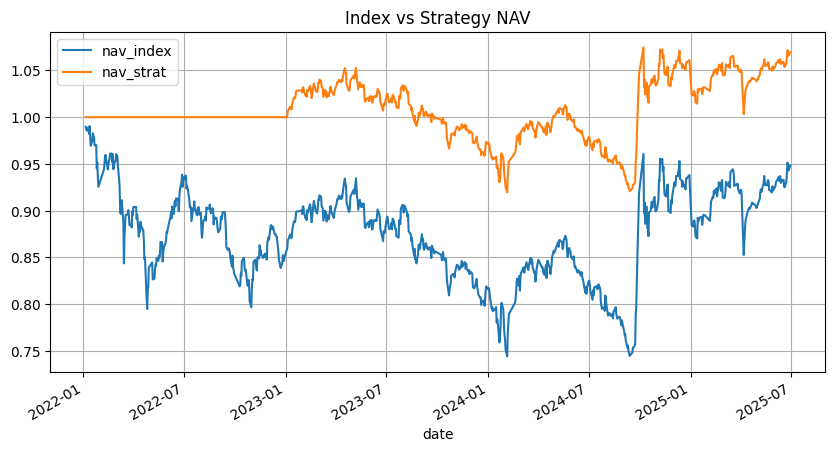

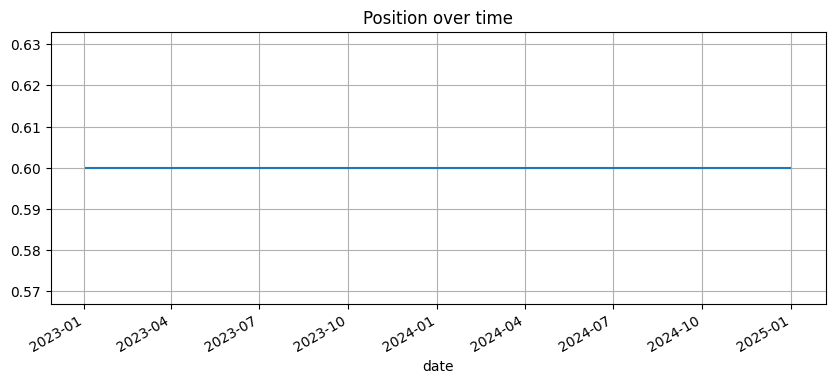

In [42]:
daily_bt, stats_bt = backtest_step_position(
    close=index_close,              # 哪怕是 DataFrame 也行
    position=step_df["position"],
    cost_bp=5.0,
    shift_n=1,
)

# 1) 打印统计
print("回测指标：")
for k, v in stats_bt.items():
    print(f"{k}: {v:.4f}")

# 2) 看最后几天的数据
print("\n日度回测结果尾部：")
print(daily_bt.tail(5))

# 3) 净值曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
daily_bt[["nav_index", "nav_strat"]].plot(ax=plt.gca())
plt.title("Index vs Strategy NAV")
plt.grid(True)
plt.show()

# 4) 仓位路径
plt.figure(figsize=(10,4))
step_df["position"].plot()
plt.title("Position over time")
plt.grid(True)
plt.show()


In [43]:
import numpy as np
import pandas as pd

# ====================== 配置：路径 & 依赖对象 ======================

# 你已经有：
# - index_logret: 指数 log 日收益（收盘-收盘）
# - index_logret_open: 指数 log 日收益（开盘-开盘）
# - features_A, features_B, features_C: 22 个原始特征拆成的三个表，index 为交易日
# 这里只需要再指定 35 个 market_* 特征文件路径：

path_market = "/Users/yulia/Desktop/clickhouse/market_indicators_20200101_20241231_20251109_132634.csv"


# ====================== 小工具 ======================

def zscore(s: pd.Series, w: int = 252, minp: int = 60) -> pd.Series:
    """滚动 Z 分数"""
    s = s.astype(float).copy()
    roll_mean = s.rolling(w, min_periods=minp).mean()
    roll_std = s.rolling(w, min_periods=minp).std()
    return (s - roll_mean) / (roll_std + 1e-8)


def _safe_col(df, name: str, idx) -> pd.Series:
    """从 df 中安全取一列并对齐到 idx；如果没有该列，则返回全 NaN 的 Series。"""
    if isinstance(df, pd.DataFrame) and (name in df.columns):
        return df[name].astype(float).reindex(idx)
    if isinstance(df, pd.Series) and (df.name == name):
        return df.astype(float).reindex(idx)
    return pd.Series(index=idx, dtype=float)


def perf_stats(ret_log: pd.Series) -> pd.Series:
    """对 log 收益率序列计算绩效指标（和你原来的一致）"""
    r = ret_log.copy().dropna()
    if r.empty:
        return pd.Series({"AnnRet": np.nan, "AnnVol": np.nan, "Sharpe": np.nan,
                          "MaxDD": np.nan, "Hit": np.nan})
    ann = np.exp(r.mean() * 252) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = (r.mean() / r.std()) * np.sqrt(252) if r.std() > 0 else np.nan
    dd = (r.cumsum() - r.cumsum().cummax())
    maxdd = 1 - np.exp(dd.min())
    hit = (r > 0).mean()
    return pd.Series({"AnnRet": ann, "AnnVol": vol, "Sharpe": sharpe, "MaxDD": maxdd, "Hit": hit})


def simulate_step_position(
    sig_01: pd.Series,
    step: float = 0.1,
    pos_min: float = 0.0,
    pos_max: float = 1.0,
    pos_init: float = 0.0,
) -> pd.Series:
    """
    根据信号 0/1 生成阶梯仓位路径：
    - sig=1 → 仓位按 step 逐步向上加，直到 pos_max
    - sig=0 → 仓位按 step 逐步向下减，直到 pos_min
    """
    idx = sig_01.index
    pos = pd.Series(index=idx, dtype=float)

    pos_prev = pos_init
    for i, t in enumerate(idx):
        sig = sig_01.iloc[i]
        if sig == 1:
            pos_now = min(pos_prev + step, pos_max)
        else:
            pos_now = max(pos_prev - step, pos_min)
        pos.iloc[i] = pos_now
        pos_prev = pos_now

    return pos


def backtest_with_cost(
    pos: pd.Series,
    index_logret_open: pd.Series,
    cost_bps: float = 5.0,
) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    """
    用“开盘对开盘”的 log 收益做回测，包含交易成本：
    - pos: 当日开盘前已经确定好的仓位（0~1 或更高）
    - index_logret_open: 指数 log(open_t / open_{t-1})
    - cost_bps: 单边交易成本（bps）
    返回：
    - ret_after: 策略 log 收益（扣成本）
    - nav_sig: 策略净值
    - nav_idx: 指数净值
    - turnover: 当日换手
    """
    # 对齐
    idx = index_logret_open.index
    pos = pos.reindex(idx).fillna(method="ffill").fillna(0.0)

    # 用前一日持仓在今日收益上生效
    pos_eff = pos.shift(1).fillna(pos.iloc[0])

    # 换手 = |Δpos|
    turnover = pos_eff.diff().abs().fillna(0.0)

    # 成本（近似）：turnover * cost率
    cost_rate = cost_bps / 10000.0
    cost = turnover * cost_rate

    # 策略 log 收益 = pos_eff * index_logret_open - cost（近似）
    ret_after = pos_eff * index_logret_open - cost

    nav_sig = ret_after.cumsum().apply(np.exp)
    nav_idx = index_logret_open.cumsum().apply(np.exp)

    return ret_after, nav_sig, nav_idx, turnover


# ====================== 读取 35 个 market_* 特征并对齐 ======================

idx = index_logret.index  # 主时间轴：和你原来的模型一致

market_raw = pd.read_csv(path_market)

# 识别日期列
if "date" in market_raw.columns:
    date_col_mkt = "date"
else:
    cand = [c for c in market_raw.columns if "date" in c.lower() or "trade" in c.lower()]
    date_col_mkt = cand[0] if cand else market_raw.columns[0]
    print(f"[market] 使用日期列: {date_col_mkt}")

market_raw["date"] = pd.to_datetime(market_raw[date_col_mkt])
market_features = (
    market_raw
    .set_index("date")
    .sort_index()
    .select_dtypes(include=[np.number])   # 只要数值列
    .reindex(idx)                         # 对齐到你的回测区间
)

print("market_features shape:", market_features.shape)


# ====================== A) 趋势（保持你原来的结构） ======================

# 方案A：两枚强正向
t1 = zscore(_safe_col(features_A, "vp_turnover_weighted", idx))
t2 = zscore(_safe_col(features_A, "vp_money_ma10_over_ma60", idx))

# 方案B增量：两枚反向（方向经你的诊断为负）
t3 = -zscore(_safe_col(features_A, "vp_price_ma10_over_ma60", idx))   # 反向
t4 = -zscore(_safe_col(features_A, "vp_momentum_20d", idx))           # 反向

trend_score = (0.6*t1 + 0.3*t2 + 0.05*t3 + 0.05*t4)


# ====================== B1) 原始情绪温度计（保持原逻辑） ======================

s1 = zscore(_safe_col(features_C, "vp_market_free_turnover_5d", idx))
s2 = zscore(_safe_col(features_C, "vp_etf_activity_share_5d", idx))
s3 = zscore(_safe_col(features_C, "vp_big_inflow_share_5d", idx))
s4 = -zscore(_safe_col(features_C, "vp_gem_active_share_5d", idx))    # 反向，小权重

sent_raw = pd.concat([s1, s2, s3, 0.3*s4], axis=1).sum(axis=1) / (3 + 0.3)
sent_smooth = sent_raw.rolling(20, min_periods=10).mean()


# ====================== B2) 新增：基于 35 个 market_* 的活跃度 / 情绪增强 ======================

# 选几类“市场整体活跃度/参与度”指标
m1 = zscore(_safe_col(market_features, "market_volume_zscore", idx))
m2 = zscore(_safe_col(market_features, "market_volume_ma_ratio", idx))
m3 = zscore(_safe_col(market_features, "market_money_ma_ratio", idx))
m4 = zscore(_safe_col(market_features, "market_money_percentile", idx))
m5 = zscore(_safe_col(market_features, "market_participation_index", idx))

market_sent_raw = pd.concat([m1, m2, m3, m4, m5], axis=1)

# 对每个日期，只平均非空列
valid_counts = (~market_sent_raw.isna()).sum(axis=1).replace(0, np.nan)
market_sent_score = (market_sent_raw.sum(axis=1) / valid_counts).fillna(0.0)

market_sent_smooth = market_sent_score.rolling(20, min_periods=10).mean()

# 合成总情绪：原有情绪占 70%，market 情绪占 30%
sent_total = (0.7 * sent_smooth.fillna(0.0) +
              0.3 * market_sent_smooth.fillna(0.0))


# ====================== C1) 拐点/拥挤 veto（保留原逻辑） ======================

congestion = zscore(_safe_col(features_B, "vp_industry_concentration_vol_20d", idx))

if congestion.notna().sum() > 30:
    hi_th = congestion.quantile(0.95)
    lo_th = congestion.quantile(0.05)
else:
    hi_th, lo_th = np.inf, -np.inf

veto = pd.Series(0.0, index=idx, dtype=float)
veto[congestion >= hi_th] = -2.0     # 拥挤高位 → 强减仓
veto[congestion <= lo_th] = +0.5     # 极度平稳 → 小加仓

consis = _safe_col(features_B, "vp_industry_turnover_consistency_20d", idx)
veto_add = pd.Series(0.0, index=idx, dtype=float)
if consis.notna().sum() > 0:
    veto_add += zscore(consis).clip(-1, 1) * 0.2

ext = _safe_col(features_B, "vp_turnover_extreme_score", idx)
if ext.notna().sum() > 0:
    veto_add += ext.apply(lambda x: -0.3 if x >= 2 else (0.1 if x <= -2 else 0.0))

veto_total_orig = (veto + veto_add).clip(-3.0, +1.0)


# ====================== C2) 新增：market_* 风险状态附加 veto ======================

rv1 = zscore(_safe_col(market_features, "market_vol_percentile", idx))
rv2 = zscore(_safe_col(market_features, "market_bb_width", idx))
rv3 = zscore(_safe_col(market_features, "market_atr", idx))
rv4 = zscore(_safe_col(market_features, "market_impact_cost", idx))

risk_raw = pd.concat([rv1, rv2, rv3, rv4], axis=1)
valid_counts_r = (~risk_raw.isna()).sum(axis=1).replace(0, np.nan)
risk_score = (risk_raw.sum(axis=1) / valid_counts_r).fillna(0.0)

if risk_score.notna().sum() > 60:
    hi_risk = risk_score.quantile(0.90)
    lo_risk = risk_score.quantile(0.10)
else:
    hi_risk, lo_risk = np.inf, -np.inf

risk_veto = pd.Series(0.0, index=idx, dtype=float)
# 极端高波动 & 高成本 → 略减仓
risk_veto[risk_score >= hi_risk] = -0.5
# 极端过于平静的环境 → 稍微减一点（防突然打断）
risk_veto[risk_score <= lo_risk] = -0.2

veto_total = (veto_total_orig + risk_veto).clip(-3.0, +1.0)


# ====================== D) 新版综合打分 → 连续仓位 ======================

upper, lower = 0.5, -0.5

# 用增强后的情绪 sent_total 替代原来的 sent_smooth
composite_score = (0.6*trend_score + 0.4*sent_total) + veto_total

pos = (composite_score - lower) / (upper - lower)
pos = pos.clip(0, 1).ewm(alpha=0.2).mean()

# ===== E) 简单收盘-收盘回测（和你原来的 E 部分对应） =====
ret_index = index_logret.copy().fillna(0.0)
ret_strategy = (pos.shift(1).fillna(0.0)) * ret_index
nav_index = ret_index.cumsum().apply(np.exp)
nav_strategy = ret_strategy.cumsum().apply(np.exp)

stats_idx = perf_stats(ret_index)
stats_sig = perf_stats(ret_strategy)
report = pd.DataFrame({"Index": stats_idx, "Strategy": stats_sig})
print("== Performance (close-close, no cost) ==")
print(report)

bt = pd.DataFrame({
    "pos": pos,
    "composite_score": composite_score,
    "trend_score": trend_score,
    "sent_smooth_orig": sent_smooth,
    "sent_total": sent_total,
    "veto_orig": veto_total_orig,
    "veto": veto_total,
    "NAV_Index": nav_index,
    "NAV_Strategy": nav_strategy,
    # 诊断用
    "t1_turnover_weighted": t1,
    "t2_money_ma10_over_ma60": t2,
    "t3_price_ma10_over_ma60_rev": t3,
    "t4_momentum_20d_rev": t4,
    "s4_gem_active_rev": s4,
    "mkt_sent": market_sent_smooth,
    "risk_score": risk_score,
}).sort_index()

print("\n== Preview ==")
print(bt[["pos", "composite_score", "NAV_Index", "NAV_Strategy"]].dropna().tail())


# ===================== F) 阈值 + 步长 敏感度分析（开盘-开盘 + 成本） =====================

# 更细的网格：
threshold_list = [round(x, 3) for x in np.arange(-0.02, 0.121, 0.01)]
step_list      = [round(x, 3) for x in np.arange(0.05, 0.31, 0.05)]

results = []

for thr in threshold_list:
    # 1) 按阈值生成 0/1 信号（>thr 看多，<=thr 看空）
    sig_01 = (composite_score > thr).astype(int)
    
    for step in step_list:
        # 2) 根据信号生成仓位路径（阶梯 + 上下限）
        pos_tmp = simulate_step_position(
            sig_01,
            step=step,
            pos_min=0.2,
            pos_max=1.2,
            pos_init=0.2
        )
        
        # 3) 用“开盘对开盘”收益做回测（更贴近实盘）
        ret_after_tmp, nav_sig_tmp, nav_idx_tmp, turnover_tmp = backtest_with_cost(
            pos_tmp,
            index_logret_open,
            cost_bps=5
        )
        
        # 4) 绩效指标
        stats = perf_stats(ret_after_tmp)
        
        # 5) 换手相关指标
        r = ret_after_tmp.dropna()
        n_days = r.shape[0]
        n_years = n_days / 252 if n_days > 0 else np.nan
        
        total_turnover = turnover_tmp.sum()                      # 整段样本的总换手
        trade_days = (turnover_tmp > 1e-6).sum()                 # 发生调仓的交易日
        turnover_per_year = total_turnover / n_years if (n_years and n_years > 0) else np.nan
        
        results.append({
            "threshold": thr,
            "step": step,
            "AnnRet": stats["AnnRet"],
            "AnnVol": stats["AnnVol"],
            "Sharpe": stats["Sharpe"],
            "MaxDD": stats["MaxDD"],
            "Hit": stats["Hit"],
            "TotalTurnover": total_turnover,
            "TurnoverPerYear": turnover_per_year,
            "TradeDays": trade_days,
            "TradeFreq": trade_days / n_days if n_days > 0 else np.nan
        })

sens_table = pd.DataFrame(results)

sens_table = sens_table.sort_values(
    by=["Sharpe", "TurnoverPerYear"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n=== Sensitivity Analysis (Fine Grid, Open-based backtest, with 35 market_* features) ===")
print(sens_table.head(30))


market_features shape: (601, 34)
== Performance (close-close, no cost) ==
           Index  Strategy
AnnRet -0.045707  0.083742
AnnVol  0.261521  0.157388
Sharpe -0.178894  0.510962
MaxDD   0.414312  0.141258
Hit     0.519135  0.404326

== Preview ==
                 pos  composite_score  NAV_Index  NAV_Strategy
date                                                          
2025-06-24  0.626547         0.161884   0.870627      1.189565
2025-06-25  0.656836         0.277989   0.882507      1.199710
2025-06-26  0.689859         0.321954   0.878864      1.196454
2025-06-27  0.715045         0.315790   0.882914      1.200255
2025-06-30  0.747051         0.375072   0.894422      1.211421

=== Sensitivity Analysis (Fine Grid, Open-based backtest, with 35 market_* features) ===
    threshold  step    AnnRet    AnnVol    Sharpe     MaxDD       Hit  \
0        0.01  0.30  0.186812  0.226262  0.756958  0.196168  0.517471   
1        0.00  0.30  0.184958  0.226773  0.748358  0.196168  0.519135   